In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#### Extracting the clean dataset of 253,680 survey responses to the CDC's BRFSS2015. The target variable Diabetes_binary has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes.

In [ ]:
path = "data/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(path)
pd.set_option('display.max_columns', None)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

The complete dataset is numerical. There are no null/missing values in the dataset.

In [4]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


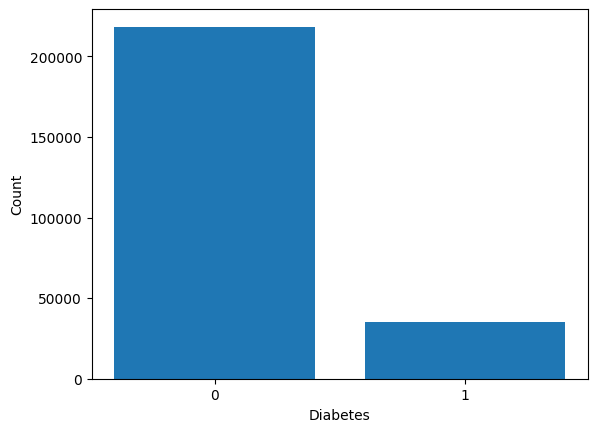

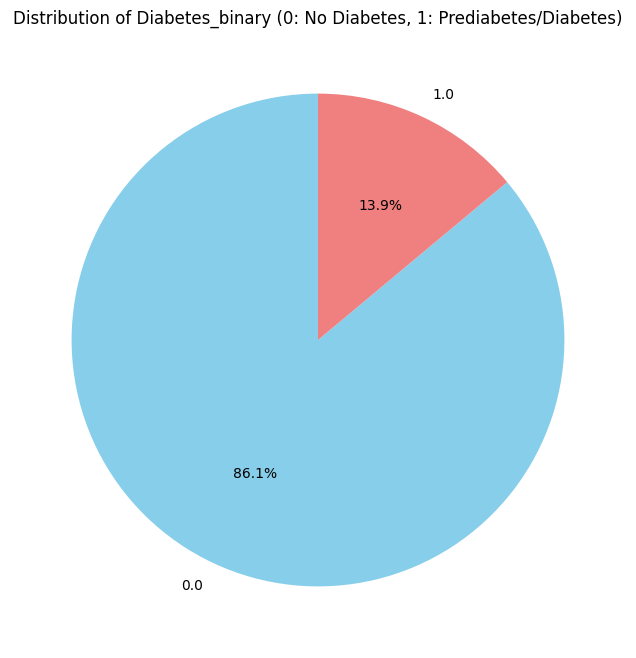

In [5]:
print(df['Diabetes_binary'].value_counts())

plt.bar(df['Diabetes_binary'].value_counts().index, df['Diabetes_binary'].value_counts().values)
plt.xticks([0, 1])
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

diabetes_percentage = df['Diabetes_binary'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 8))
plt.pie(diabetes_percentage, labels=diabetes_percentage.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Diabetes_binary (0: No Diabetes, 1: Prediabetes/Diabetes)')
plt.show()

We can see that the dataset is highly imbalanced and would need preprocessing to improve the imbalance. . Over 86% of the data represents individuals without diabetes (0.0) compared to those with prediabetes/diabetes.

#### Test-train split with stratified sampling

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [7]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(202944, 21)
(50736, 21)


### Detailed Exploratory Data Analysis for Scaling Decisions

In [8]:
print("Descriptive statistics for X_train:")
display(X_train.describe())

Descriptive statistics for X_train:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000,202944.000000
mean,0.428995,0.424304,0.962418,28.377961,0.442861,0.040405,0.094248,0.756992,0.634426,0.811426,0.055730,0.951149,0.084624,2.511836,3.189796,4.250818,0.168160,0.441013,8.032827,5.049925,6.050832
std,0.494934,0.494238,0.190183,6.598293,0.496726,0.196908,0.292174,0.428901,0.481592,0.391171,0.229399,0.215557,0.278323,1.068378,7.417614,8.725646,0.374009,0.496510,3.051388,0.986384,2.072661
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [9]:
# Identify binary and continuous features
binary_features = [col for col in X_train.columns if X_train[col].nunique() <= 2]
continuous_features = [col for col in X_train.columns if col not in binary_features]

print(f"Binary Features: {binary_features}")
print(f"Continuous Features: {continuous_features}")

Binary Features: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Continuous Features: ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


#### Outlier Detection and Distribution for Continuous Features

(5000, 23)
Diabetes
No diabetes    2500
Diabetes       2500
Name: count, dtype: int64
Columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary', 'Diabetes']


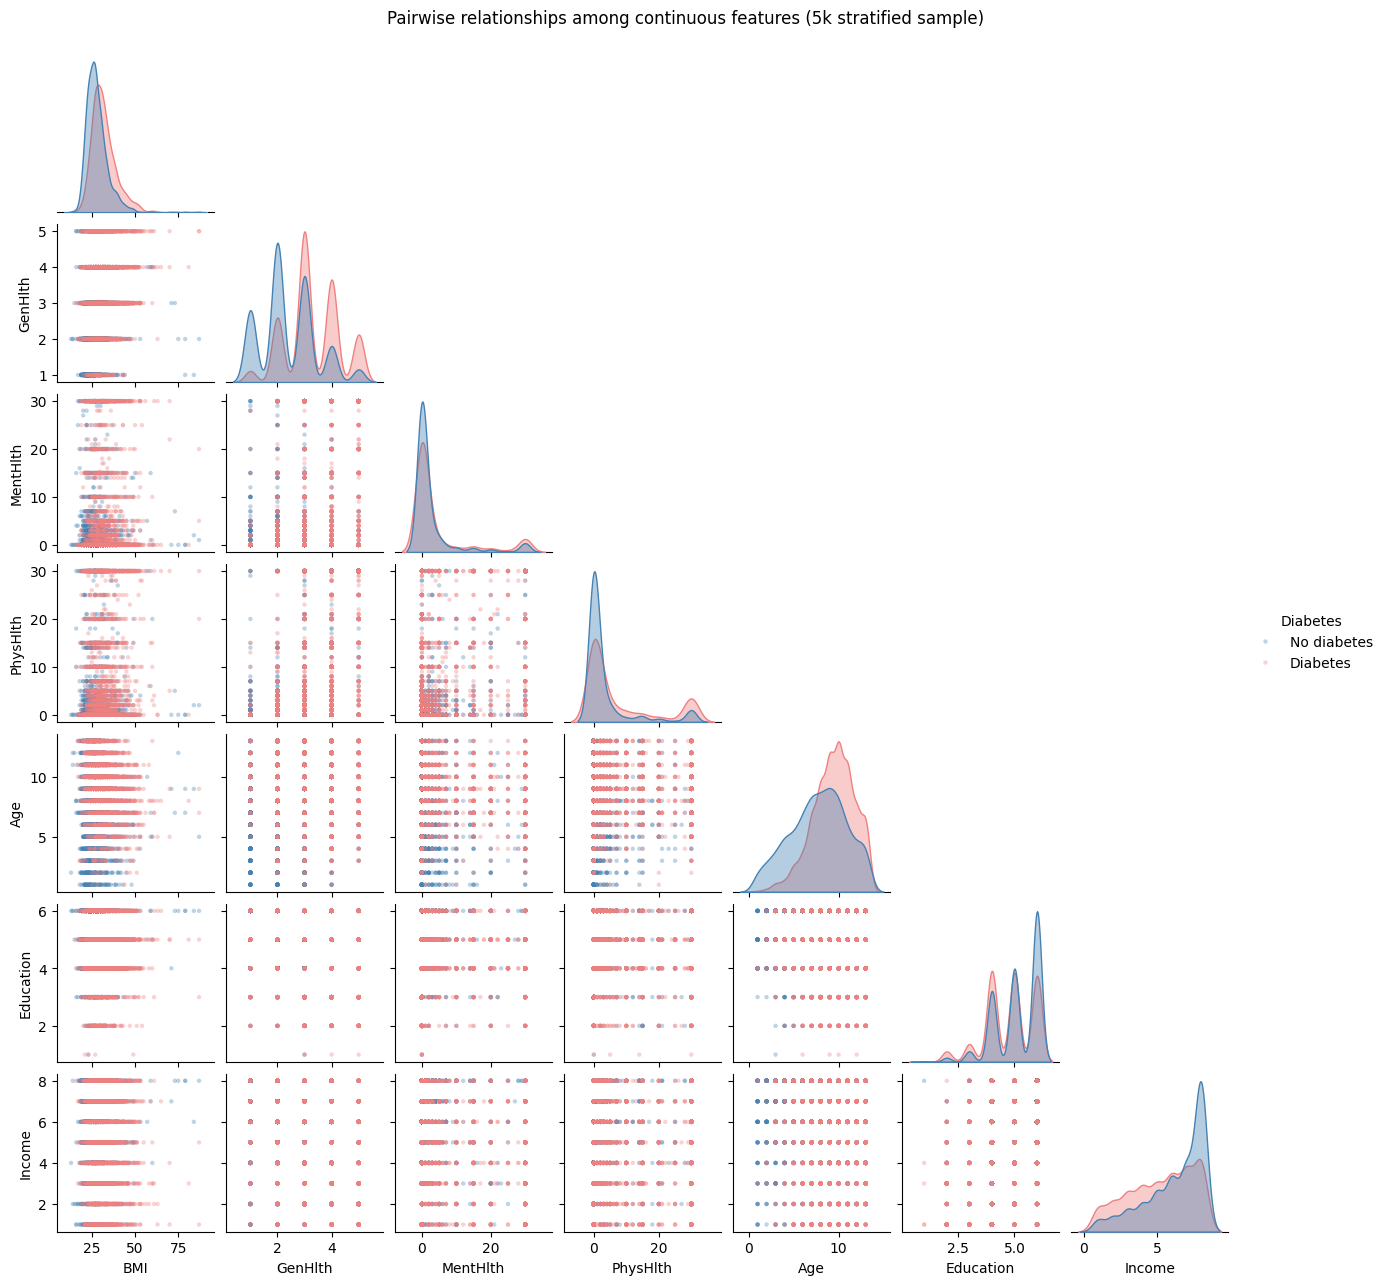

In [10]:
# Build a labeled train-only frame
train_df = X_train.copy()
train_df['Diabetes_binary'] = y_train.values

# Sample each class directly — no groupby shenanigans
neg = train_df[train_df['Diabetes_binary'] == 0.0].sample(n=2500, random_state=42)
pos = train_df[train_df['Diabetes_binary'] == 1.0].sample(n=2500, random_state=42)
sample = pd.concat([neg, pos], ignore_index=True)

sample['Diabetes'] = sample['Diabetes_binary'].map({0.0: 'No diabetes',
                                                    1.0: 'Diabetes'})

print(sample.shape)
print(sample['Diabetes'].value_counts())
print('Columns:', list(sample.columns))   # sanity check

continuous_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth',
                       'Age', 'Education', 'Income']

g = sns.pairplot(
    sample,
    vars=continuous_features,
    hue='Diabetes',
    hue_order=['No diabetes', 'Diabetes'],
    palette={'No diabetes': 'steelblue', 'Diabetes': 'lightcoral'},
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 10, 'edgecolor': 'none'},
    diag_kws={'common_norm': False, 'fill': True, 'alpha': 0.4},
    corner=True,
    height=1.8,
)
g.fig.suptitle('Pairwise relationships among continuous features (5k stratified sample)',
               y=1.02)
plt.show()

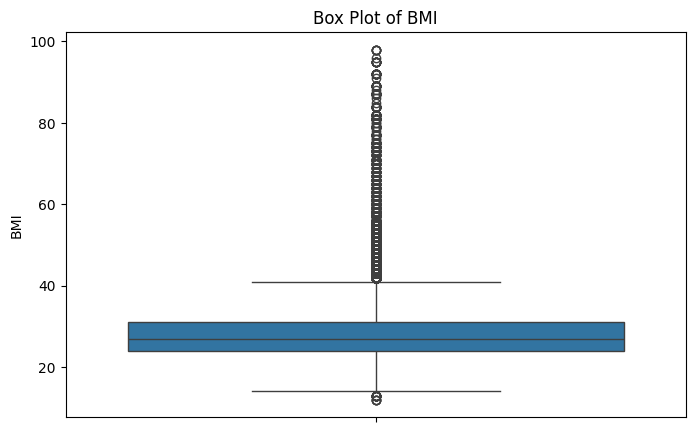

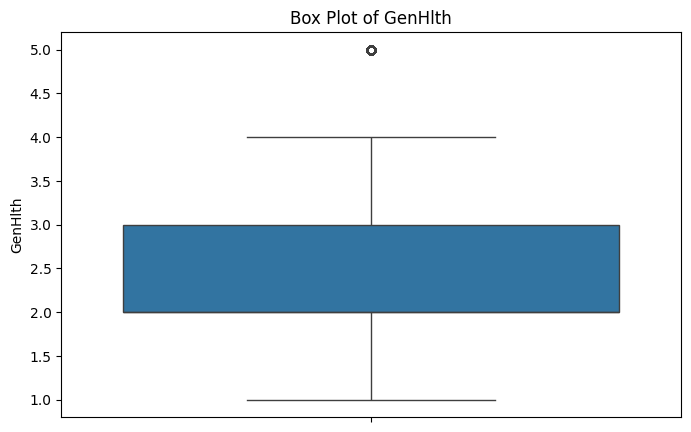

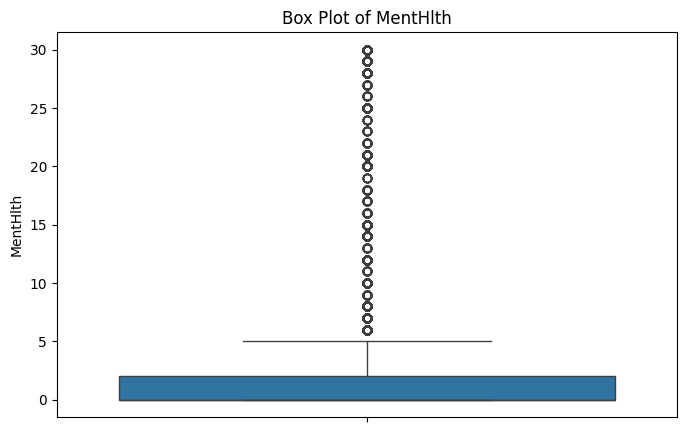

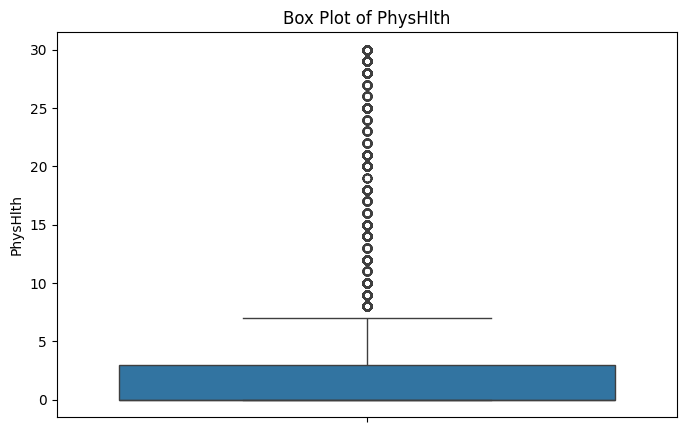

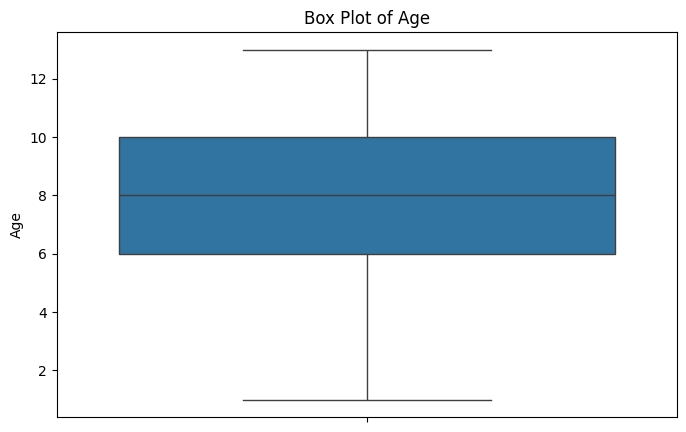

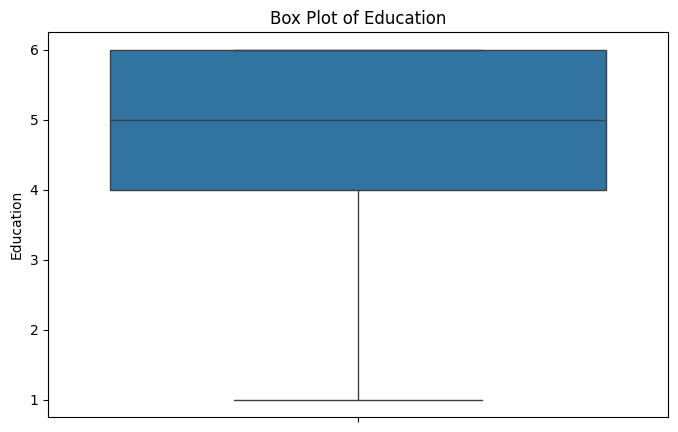

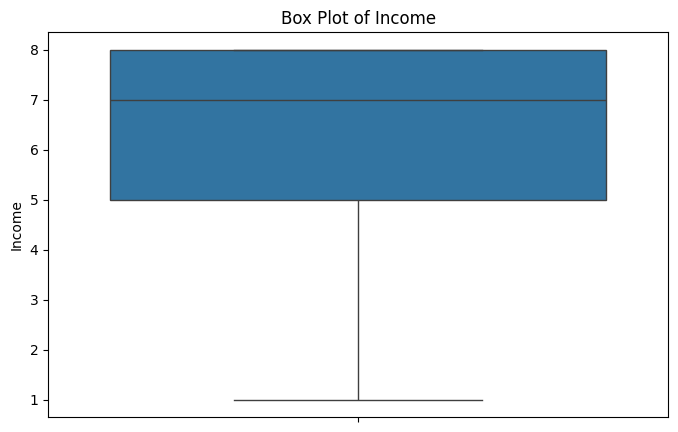

In [ ]:
for col in continuous_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

#### Correlation Matrix

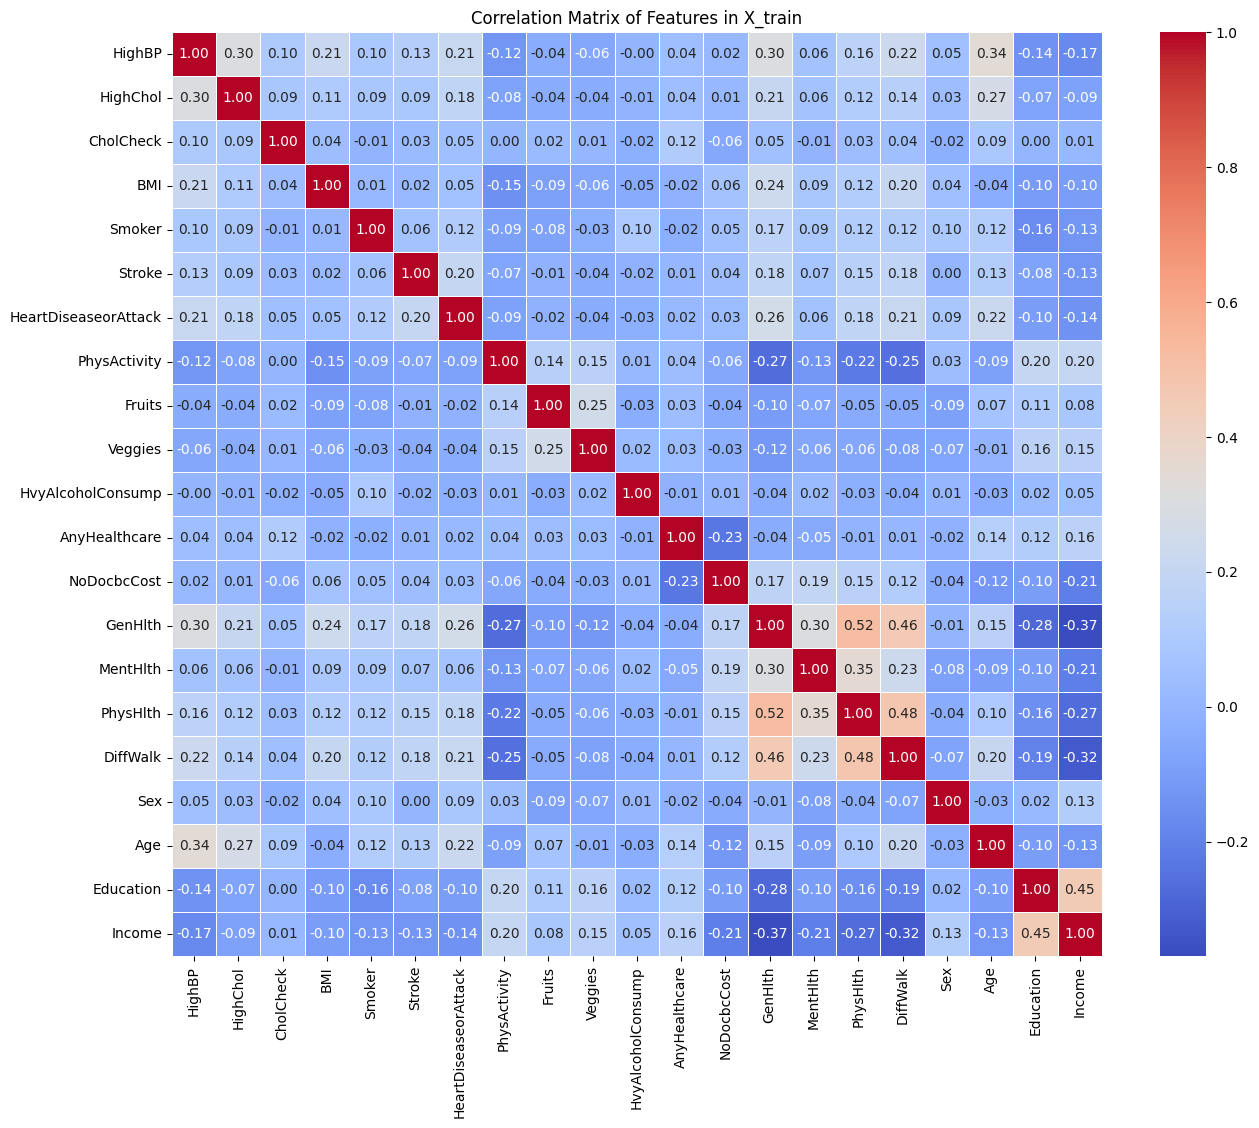

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features in X_train')
plt.show()

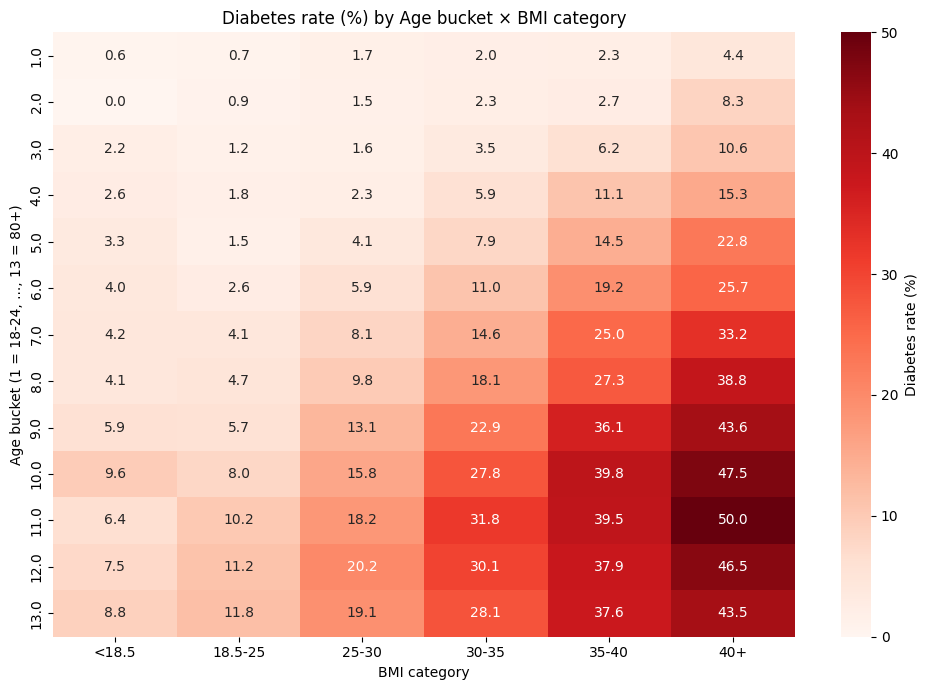

In [ ]:

bmi_bins   = [0, 18.5, 25, 30, 35, 40, 100]
bmi_labels = ['<18.5', '18.5-25', '25-30', '30-35', '35-40', '40+']

eda = df.copy()
eda['BMI_bin'] = pd.cut(eda['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

rate = eda.pivot_table(
    index='Age', columns='BMI_bin',
    values='Diabetes_binary', aggfunc='mean', observed=True,
)
counts = eda.pivot_table(
    index='Age', columns='BMI_bin',
    values='Diabetes_binary', aggfunc='count', observed=True,
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    rate * 100, annot=True, fmt='.1f', cmap='Reds',
    cbar_kws={'label': 'Diabetes rate (%)'},
    mask=counts < 30,
)
plt.title('Diabetes rate (%) by Age bucket × BMI category')
plt.xlabel('BMI category')
plt.ylabel('Age bucket (1 = 18-24, ..., 13 = 80+)')
plt.tight_layout()
plt.show()

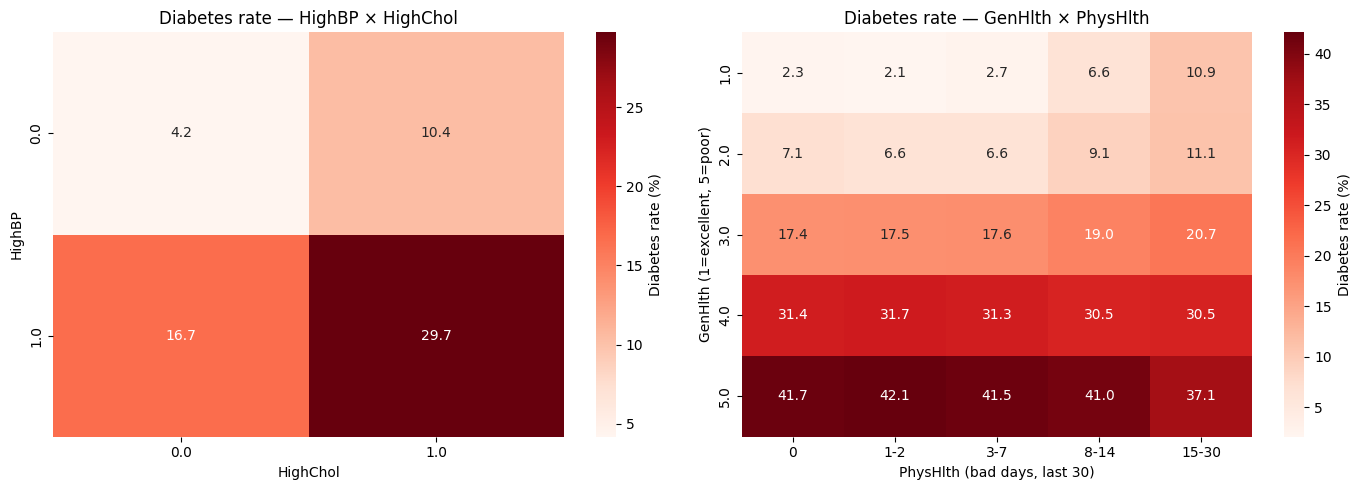

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- HighBP × HighChol (2x2) ---
rate_bp_chol = df.pivot_table(
    index='HighBP', columns='HighChol',
    values='Diabetes_binary', aggfunc='mean',
)
sns.heatmap(rate_bp_chol * 100, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Diabetes rate (%)'}, ax=axes[0])
axes[0].set_title('Diabetes rate — HighBP × HighChol')
axes[0].set_xlabel('HighChol'); axes[0].set_ylabel('HighBP')

# --- GenHlth (1-5) × PhysHlth bucketed ---
eda = df.copy()
eda['PhysHlth_bin'] = pd.cut(
    eda['PhysHlth'],
    bins=[-1, 0, 2, 7, 14, 30],
    labels=['0', '1-2', '3-7', '8-14', '15-30'],
)
rate_gen_phys = eda.pivot_table(
    index='GenHlth', columns='PhysHlth_bin',
    values='Diabetes_binary', aggfunc='mean', observed=True,
)
counts_gen_phys = eda.pivot_table(
    index='GenHlth', columns='PhysHlth_bin',
    values='Diabetes_binary', aggfunc='count', observed=True,
)
sns.heatmap(rate_gen_phys * 100, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Diabetes rate (%)'},
            mask=counts_gen_phys < 30, ax=axes[1])
axes[1].set_title('Diabetes rate — GenHlth × PhysHlth')
axes[1].set_xlabel('PhysHlth (bad days, last 30)')
axes[1].set_ylabel('GenHlth (1=excellent, 5=poor)')

plt.tight_layout()
plt.show()

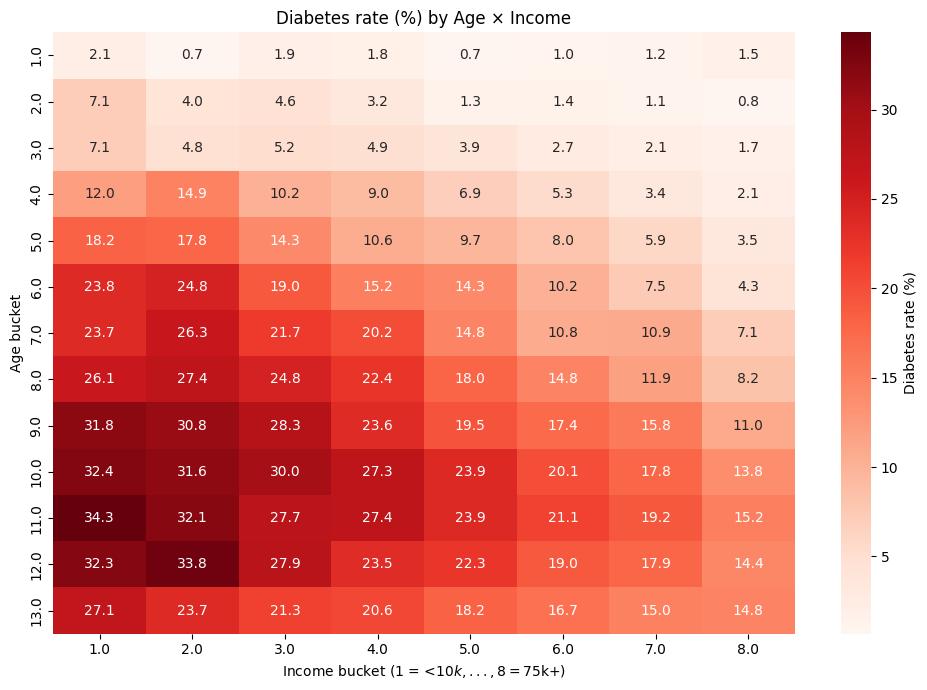

In [ ]:
rate_age_inc = df.pivot_table(
    index='Age', columns='Income',
    values='Diabetes_binary', aggfunc='mean',
)
counts_age_inc = df.pivot_table(
    index='Age', columns='Income',
    values='Diabetes_binary', aggfunc='count',
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    rate_age_inc * 100, annot=True, fmt='.1f', cmap='Reds',
    cbar_kws={'label': 'Diabetes rate (%)'},
    mask=counts_age_inc < 30,
)
plt.title('Diabetes rate (%) by Age × Income')
plt.xlabel('Income bucket (1 = <$10k, ..., 8 = $75k+)')
plt.ylabel('Age bucket')
plt.tight_layout()
plt.show()

Distribution of binary features

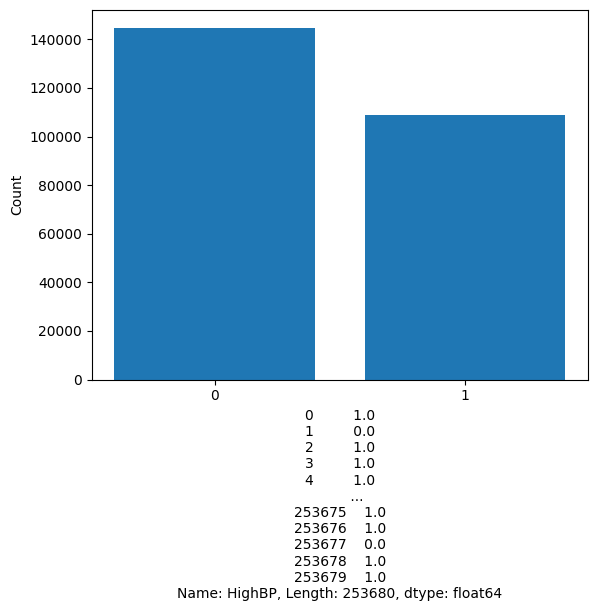

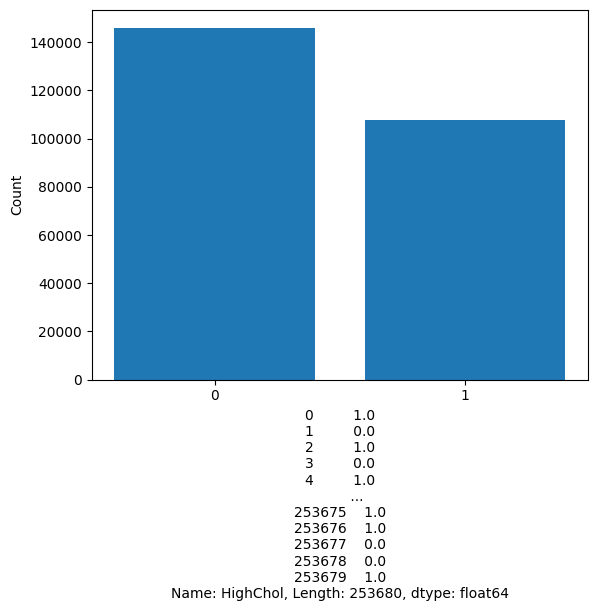

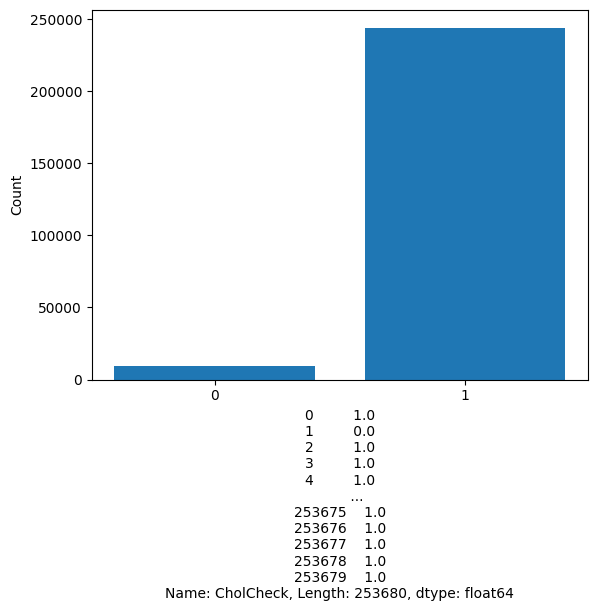

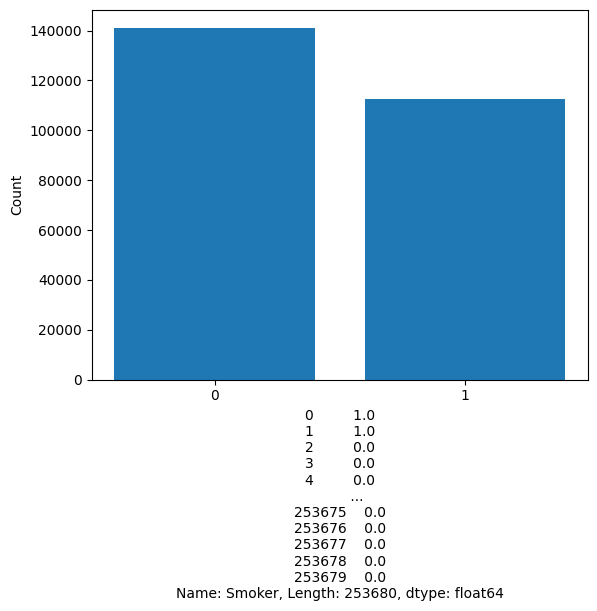

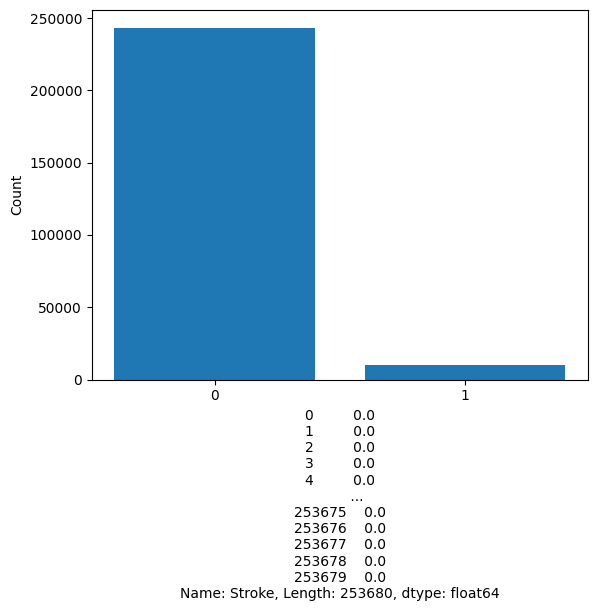

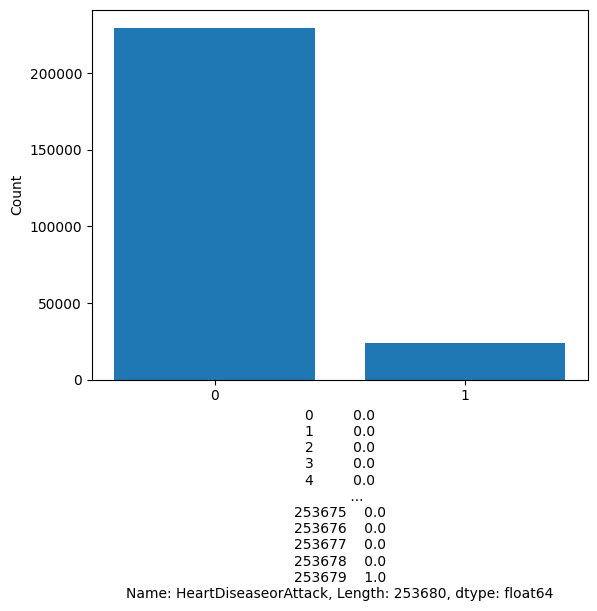

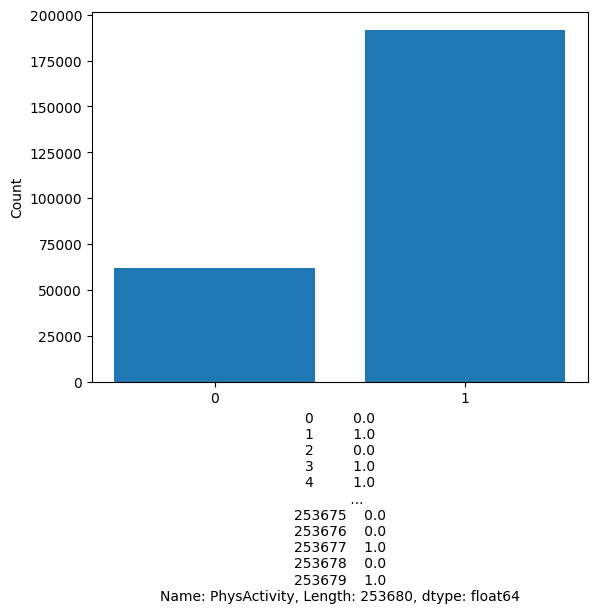

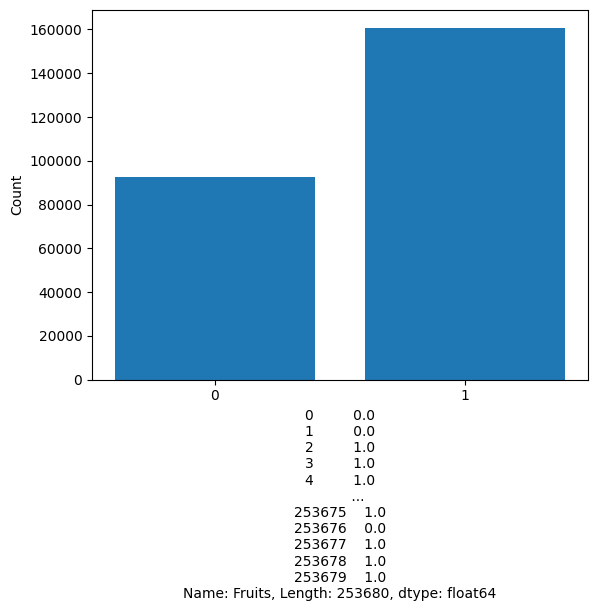

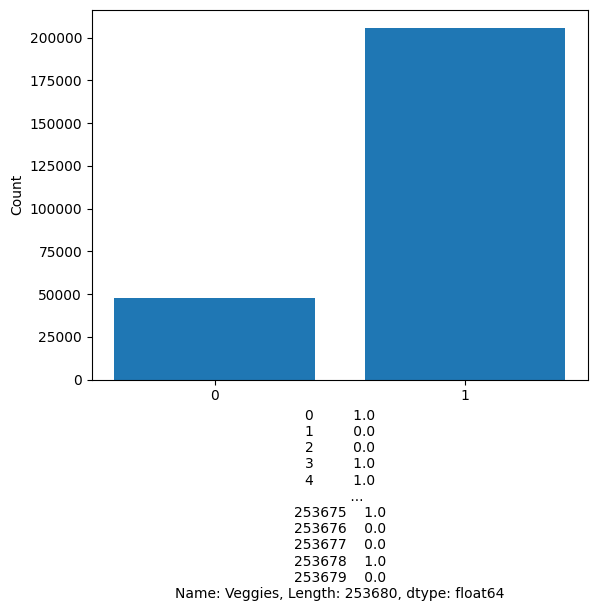

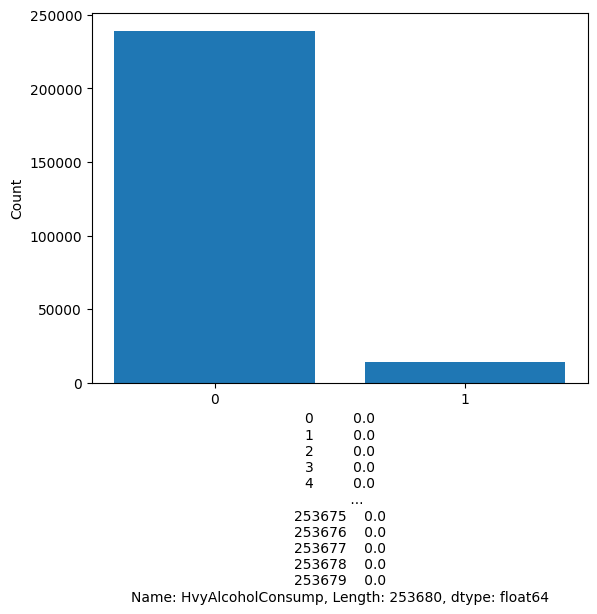

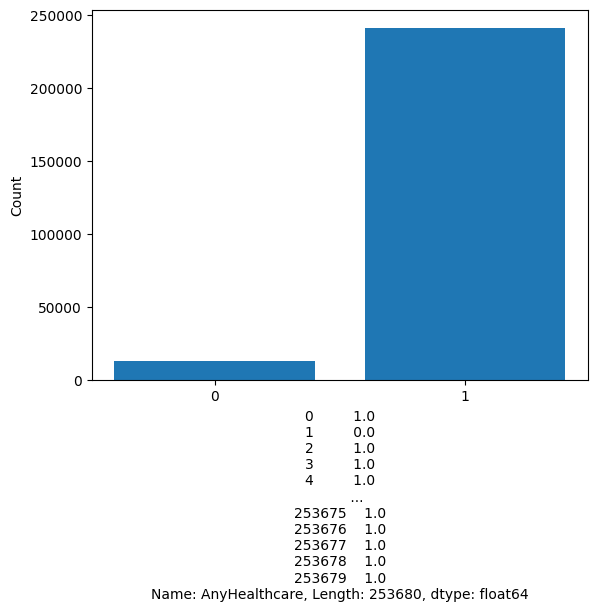

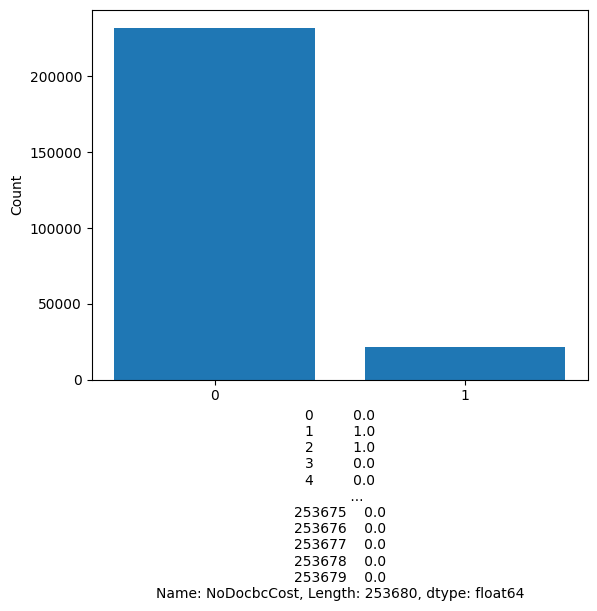

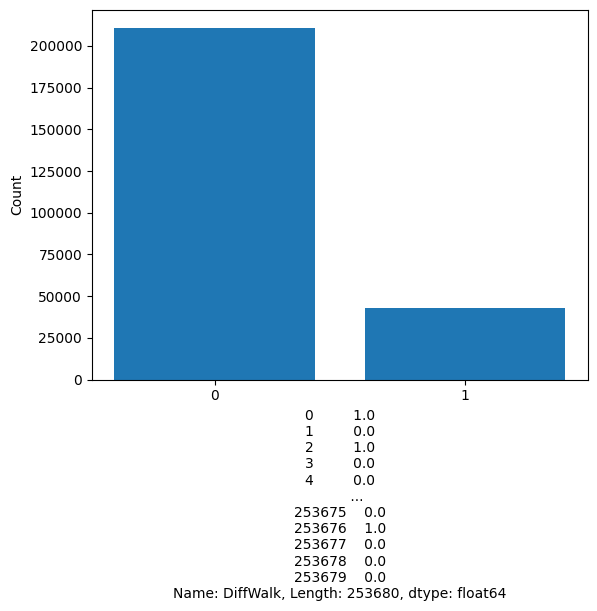

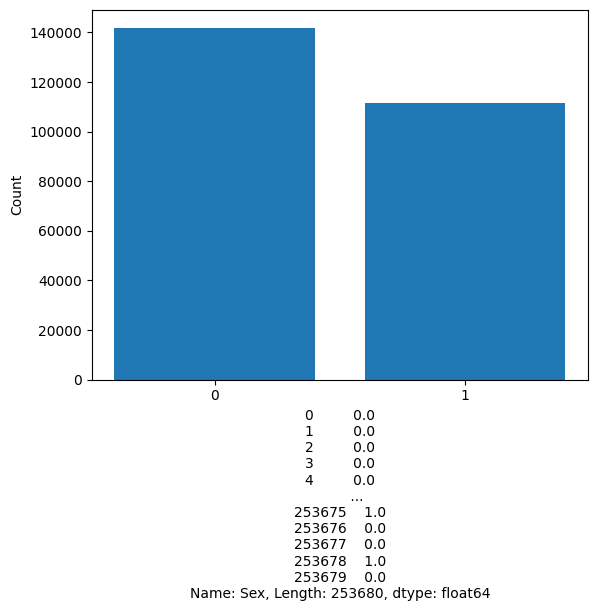

In [ ]:
for col in binary_features:
    plt.bar(df[col].value_counts().index, df[col].value_counts().values)
    plt.xticks([0, 1])
    plt.xlabel(df[col])
    plt.ylabel('Count')
    plt.show()

## Feature Engineering


In [ ]:
def engineer_features(X):
    """Return a copy of X with Tier-1 engineered features appended.

    Pure function — no fitting, no data-dependent statistics.
    Safe to apply to X_train and X_test independently (no leakage).
    """
    X = X.copy()

    # ---- 1. Interaction / cross terms ------------------------------------
    # Age x BMI: risk explodes in the older-and-obese corner of the heatmap
    X['BMI_x_Age'] = X['BMI'] * X['Age']

    # HighBP x HighChol: super-additive (+7pp over the additive expectation)
    X['HighBP_x_HighChol'] = X['HighBP'] * X['HighChol']

    # Age x (inverted) Income: older + poorer compounds risk
    # Income is 1..8 (low..high); flip it so larger = more disadvantaged
    X['Age_x_IncomeInv'] = X['Age'] * (9 - X['Income'])

    # ---- 2. Clinical BMI categories (one-hot) ----------------------------
    bmi_bins   = [0, 18.5, 25, 30, 35, 40, 200]
    bmi_labels = ['under', 'normal', 'overweight', 'obese1', 'obese2', 'obese3']
    bmi_cat = pd.cut(X['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)
    bmi_dummies = pd.get_dummies(bmi_cat, prefix='BMIcat', drop_first=True).astype(float)
    X = pd.concat([X, bmi_dummies], axis=1)

    # ---- 3. Comorbidity / healthy-behavior counts ------------------------
    risk_flags = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack',
                  'Smoker', 'DiffWalk', 'HvyAlcoholConsump']
    healthy_flags = ['PhysActivity', 'Fruits', 'Veggies']

    X['risk_score']    = X[risk_flags].sum(axis=1)       # 0..7
    X['healthy_score'] = X[healthy_flags].sum(axis=1)    # 0..3

    return X


# Apply to the un-preprocessed splits (preserves column names & dtypes)
X_train_fe = engineer_features(X_train)
X_test_fe  = engineer_features(X_test)

new_cols = [c for c in X_train_fe.columns if c not in X_train.columns]
print(f"Added {len(new_cols)} features:")
for c in new_cols:
    print(f"  - {c}")
print(f"\nX_train_fe: {X_train_fe.shape}   X_test_fe: {X_test_fe.shape}")
X_train_fe.head()

Added 10 features:
  - BMI_x_Age
  - HighBP_x_HighChol
  - Age_x_IncomeInv
  - BMIcat_normal
  - BMIcat_overweight
  - BMIcat_obese1
  - BMIcat_obese2
  - BMIcat_obese3
  - risk_score
  - healthy_score

X_train_fe: (202944, 31)   X_test_fe: (50736, 31)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_x_Age,HighBP_x_HighChol,Age_x_IncomeInv,BMIcat_normal,BMIcat_overweight,BMIcat_obese1,BMIcat_obese2,BMIcat_obese3,risk_score,healthy_score
153147,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0,56.0,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0
176137,1.0,0.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,13.0,4.0,7.0,299.0,0.0,26.0,1.0,0.0,0.0,0.0,0.0,2.0,3.0
175578,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,261.0,1.0,9.0,0.0,1.0,0.0,0.0,0.0,2.0,3.0
177887,1.0,1.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,1.0,7.0,4.0,7.0,273.0,1.0,14.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0
182143,0.0,1.0,1.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,7.0,5.0,1.0,112.0,0.0,56.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0


## Preprocessing Pipeline

In [ ]:
# Explicit feature groups for the ColumnTransformer (matches the EDA strategy above)
standard_features = ['BMI', 'Age', 'Education', 'Income']   # roughly normal / mild skew
robust_features   = ['MentHlth', 'PhysHlth']                # right-skewed, heavy outliers
minmax_features   = ['GenHlth']                             # ordinal 1-5, preserve order in [0,1]
# binary_features is reused from the earlier EDA cell (14 binary columns)
# Re-route each new column to the appropriate scaler
standard_features_fe = standard_features + ['BMI_x_Age', 'Age_x_IncomeInv']
robust_features_fe   = robust_features                   # unchanged
minmax_features_fe   = minmax_features + ['risk_score', 'healthy_score']
binary_features_fe   = binary_features + [
    'HighBP_x_HighChol',
    'BMIcat_normal', 'BMIcat_overweight', 'BMIcat_obese1',
    'BMIcat_obese2', 'BMIcat_obese3',
]

covered = set(standard_features_fe + robust_features_fe
              + minmax_features_fe + binary_features_fe)
missing = set(X_train_fe.columns) - covered
extra   = covered - set(X_train_fe.columns)
assert not missing and not extra, f"missing={missing}, extra={extra}"
print(f"All {len(covered)} features mapped correctly.")


All 31 features mapped correctly.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), standard_features),
        ('robust',   RobustScaler(),   robust_features),
        ('minmax',   MinMaxScaler(),   minmax_features),
        ('binary',   'passthrough',    binary_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform='pandas')  # keep DataFrame structure / column names
preprocessor

ColumnTransformer(transformers=[('standard', StandardScaler(),
                                 ['BMI', 'Age', 'Education', 'Income']),
                                ('robust', RobustScaler(),
                                 ['MentHlth', 'PhysHlth']),
                                ('minmax', MinMaxScaler(), ['GenHlth']),
                                ('binary', 'passthrough',
                                 ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
                                  'Stroke', 'HeartDiseaseorAttack',
                                  'PhysActivity', 'Fruits', 'Veggies',
                                  'HvyAlcoholConsump', 'AnyHealthcare',
                                  'NoDocbcCost', 'DiffWalk', 'Sex'])],
                  verbose_feature_names_out=False)

In [ ]:
# Fit on TRAINING data only (prevents leakage), transform both splits
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")
X_train_processed.head()

X_train_processed: (202944, 21)
X_test_processed:  (50736, 21)


,BMI,Age,Education,Income,MentHlth,PhysHlth,GenHlth,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
153147,-0.057282,-1.977081,-1.064421,-0.506998,0.0,0.0,0.25,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
176137,-0.815055,1.627845,-1.064421,0.457948,0.0,0.0,0.25,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
175578,0.094273,0.316963,0.963192,0.940421,0.0,0.0,0.00,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
177887,1.609820,-0.338479,-1.064421,0.457948,0.0,0.0,0.75,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
182143,-1.875938,-0.338479,-0.050614,-2.436889,15.0,10.0,1.00,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0


## Addressing Class Imbalance


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter


In [ ]:

print(f"Before SMOTE -> {dict(Counter(y_train))}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print(f"After  SMOTE -> {dict(Counter(y_train_balanced))}")
print(f"X_train_balanced shape: {X_train_balanced.shape}")
print(f"y_train_balanced shape: {y_train_balanced.shape}")

Before SMOTE -> {0.0: 174667, 1.0: 28277}
After  SMOTE -> {0.0: 174667, 1.0: 174667}
X_train_balanced shape: (349334, 21)
y_train_balanced shape: (349334,)


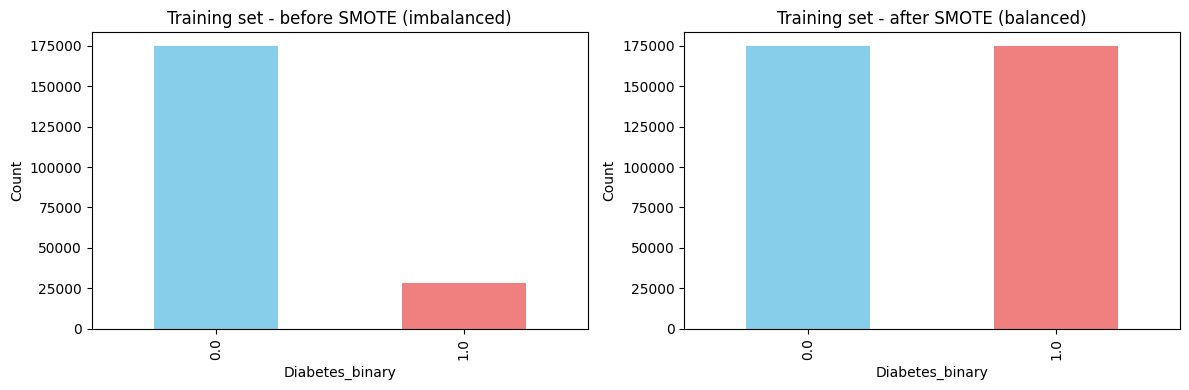

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_train).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['skyblue', 'lightcoral']
)
axes[0].set_title('Training set - before SMOTE (imbalanced)')
axes[0].set_xlabel('Diabetes_binary')
axes[0].set_ylabel('Count')

pd.Series(y_train_balanced).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['skyblue', 'lightcoral']
)
axes[1].set_title('Training set - after SMOTE (balanced)')
axes[1].set_xlabel('Diabetes_binary')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Pipeline for feature engineered data

In [ ]:

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), standard_features_fe),
        ('robust',   RobustScaler(),   robust_features_fe),
        ('minmax',   MinMaxScaler(),   minmax_features_fe),
        ('binary',   'passthrough',    binary_features_fe),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
preprocessor_fe.set_output(transform='pandas')

# Fit on TRAIN only
X_train_processed_fe = preprocessor_fe.fit_transform(X_train_fe)
X_test_processed_fe  = preprocessor_fe.transform(X_test_fe)

# Re-run SMOTE on the engineered features for the balanced track
smote_fe = SMOTE(random_state=42)
X_train_balanced_fe, y_train_balanced_fe = smote_fe.fit_resample(
    X_train_processed_fe, y_train
)

print(f"X_train_processed_fe: {X_train_processed_fe.shape}")
print(f"X_test_processed_fe:  {X_test_processed_fe.shape}")
print(f"X_train_balanced_fe:  {X_train_balanced_fe.shape}")
X_train_processed_fe.head()

X_train_processed_fe: (202944, 31)
X_test_processed_fe:  (50736, 31)
X_train_balanced_fe:  (349334, 31)


,BMI,Age,Education,Income,BMI_x_Age,Age_x_IncomeInv,MentHlth,PhysHlth,GenHlth,risk_score,healthy_score,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,HighBP_x_HighChol,BMIcat_normal,BMIcat_overweight,BMIcat_obese1,BMIcat_obese2,BMIcat_obese3
153147,-0.057282,-1.977081,-1.064421,-0.506998,-1.746889,-0.778137,0.0,0.0,0.25,0.142857,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
176137,-0.815055,1.627845,-1.064421,0.457948,0.732246,0.071314,0.0,0.0,0.25,0.285714,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
175578,0.094273,0.316963,0.963192,0.940421,0.344562,-0.730945,0.0,0.0,0.00,0.285714,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
177887,1.609820,-0.338479,-1.064421,0.457948,0.466989,-0.494987,0.0,0.0,0.75,0.285714,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
182143,-1.875938,-0.338479,-0.050614,-2.436889,-1.175565,1.487064,15.0,10.0,1.00,0.428571,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Modeling

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
)

# Shared store — every call to evaluate_model appends one row here
results = {}

def evaluate_model(model, X_test, y_test, name, plot=True, store=results):
    """Evaluate a fitted binary classifier and return its metrics dict.

    Prints a classification report, plots confusion matrix + ROC + PR curve
    (when plot=True), and records the metrics under `store[name]` for later
    side-by-side comparison across models.
    """
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':    accuracy_score(y_test, y_pred),
        'precision_0': precision_score(y_test, y_pred, pos_label=0),
        'recall_0':    recall_score(y_test, y_pred, pos_label=0),
        'f1_0':        f1_score(y_test, y_pred, pos_label=0),
        'precision_1': precision_score(y_test, y_pred, pos_label=1),
        'recall_1':    recall_score(y_test, y_pred, pos_label=1),
        'f1_1':        f1_score(y_test, y_pred, pos_label=1),
        'macro_f1':    f1_score(y_test, y_pred, average='macro'),
        'roc_auc':     roc_auc_score(y_test, y_proba),
        'pr_auc':      average_precision_score(y_test, y_proba),
    }

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, digits=4,
                                target_names=['No diabetes (0)', 'Diabetes (1)']))
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}   PR-AUC: {metrics['pr_auc']:.4f}\n")

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['No diabetes', 'Diabetes'],
                    yticklabels=['No diabetes', 'Diabetes'], cbar=False)
        axes[0].set_title(f'{name} — Confusion Matrix')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

        RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=name)
        axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[1].set_title(f'{name} — ROC (AUC={metrics["roc_auc"]:.3f})')

        PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], name=name)
        axes[2].set_title(f'{name} — PR (AP={metrics["pr_auc"]:.3f})')

        plt.tight_layout()
        plt.show()

    store[name] = metrics
    return metrics

## Logistic Regression


===== LR (imbalanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8776    0.9760    0.9242     43667
   Diabetes (1)     0.5175    0.1590    0.2433      7069

       accuracy                         0.8622     50736
      macro avg     0.6975    0.5675    0.5837     50736
   weighted avg     0.8274    0.8622    0.8293     50736

ROC-AUC: 0.8192   PR-AUC: 0.3943



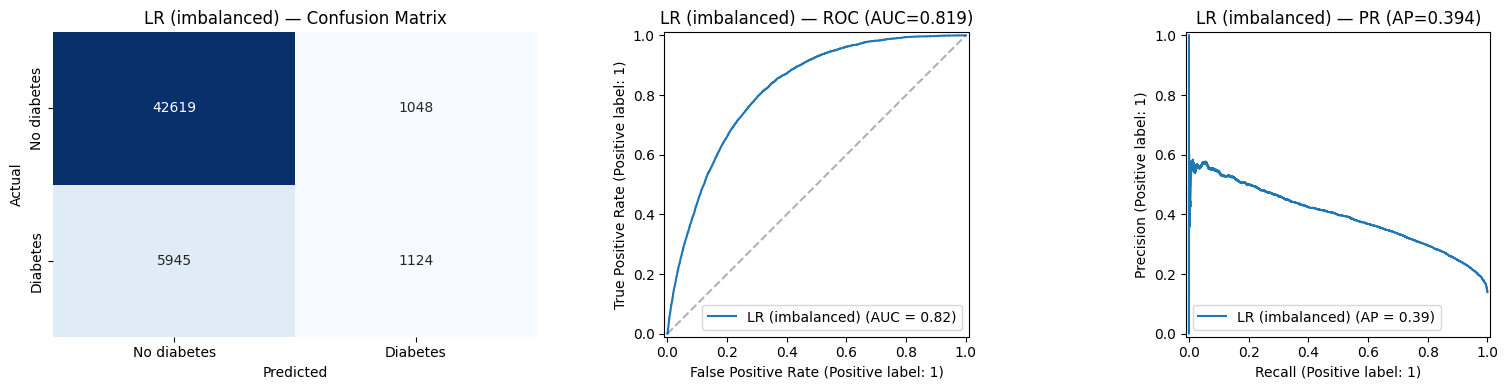

{'accuracy': 0.8621688741721855,
 'precision_0': 0.8775842187628696,
 'recall_0': 0.9760001832047084,
 'f1_0': 0.9241795058060739,
 'precision_1': 0.5174953959484346,
 'recall_1': 0.15900410241901258,
 'f1_1': 0.24326371604804675,
 'macro_f1': 0.5837216109270603,
 'roc_auc': 0.8191844751516353,
 'pr_auc': 0.39425341218935495}

In [ ]:
from sklearn.linear_model import LogisticRegression

# Track 1 — baseline on the imbalanced training data
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_processed, y_train)

evaluate_model(lr_base, X_test_processed, y_test, name='LR (imbalanced)')

===== LR (SMOTE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9496    0.7280    0.8242     43667
   Diabetes (1)     0.3118    0.7612    0.4424      7069

       accuracy                         0.7326     50736
      macro avg     0.6307    0.7446    0.6333     50736
   weighted avg     0.8607    0.7326    0.7710     50736

ROC-AUC: 0.8175   PR-AUC: 0.3894



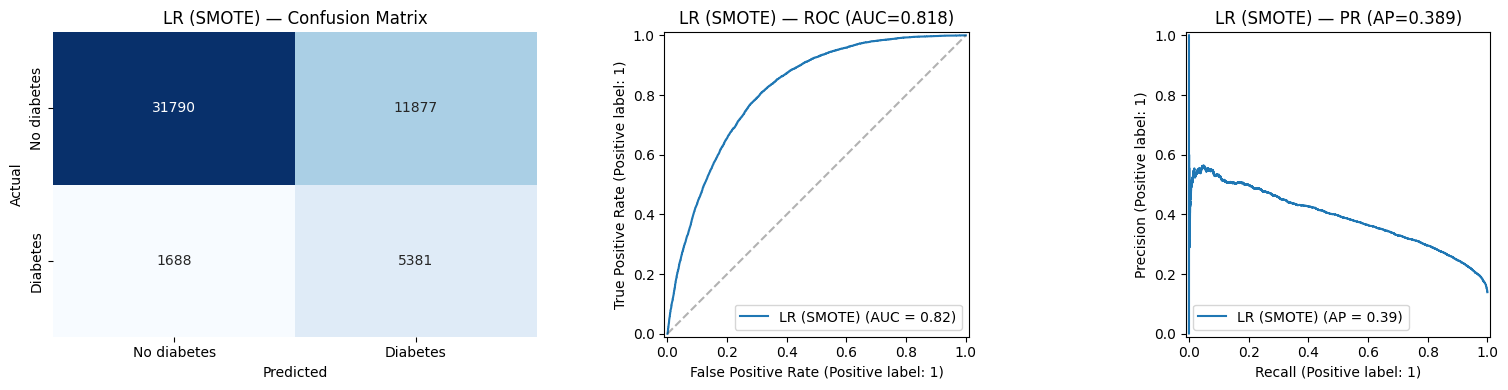

{'accuracy': 0.7326356039104384,
 'precision_0': 0.9495788278869706,
 'recall_0': 0.7280097098495432,
 'f1_0': 0.8241622917881911,
 'precision_1': 0.31179742728010196,
 'recall_1': 0.761210920922337,
 'f1_1': 0.4423891149751305,
 'macro_f1': 0.6332757033816608,
 'roc_auc': 0.8175268794321722,
 'pr_auc': 0.38942704793759647}

In [ ]:
# Track 2 — SMOTE-balanced training data
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_balanced, y_train_balanced)

evaluate_model(lr_smote, X_test_processed, y_test, name='LR (SMOTE)')

===== LR (class_weight=balanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9494    0.7268    0.8233     43667
   Diabetes (1)     0.3108    0.7609    0.4413      7069

       accuracy                         0.7316     50736
      macro avg     0.6301    0.7439    0.6323     50736
   weighted avg     0.8605    0.7316    0.7701     50736

ROC-AUC: 0.8196   PR-AUC: 0.3926



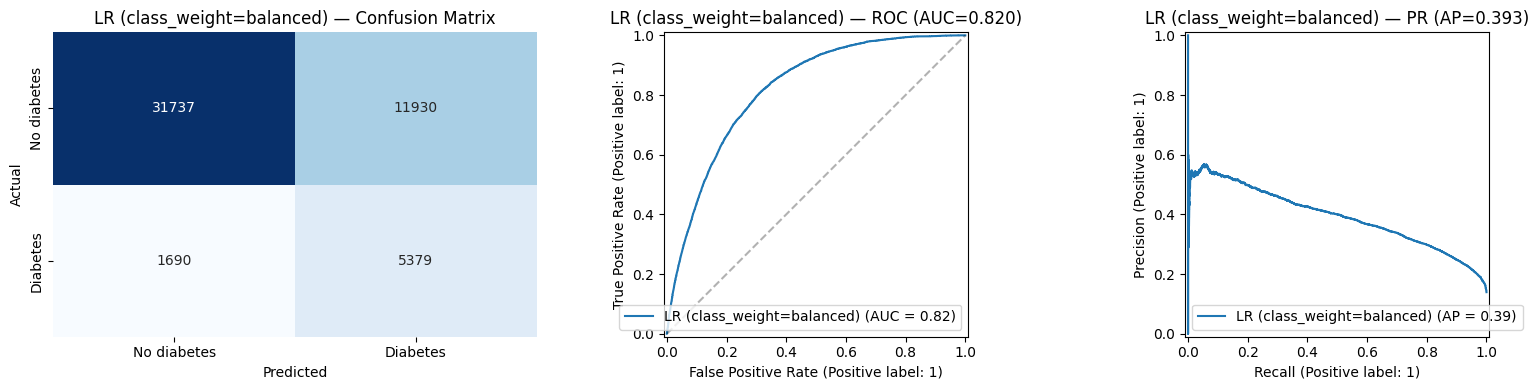

{'accuracy': 0.7315515610217597,
 'precision_0': 0.9494420677895115,
 'recall_0': 0.7267959786566515,
 'f1_0': 0.8233325550626508,
 'precision_1': 0.31076318678144316,
 'recall_1': 0.7609279954731928,
 'f1_1': 0.4412995323652473,
 'macro_f1': 0.632316043713949,
 'roc_auc': 0.8196265676281381,
 'pr_auc': 0.39258048134064477}

In [ ]:
# Track 3 — class_weight='balanced': reweights the loss without resampling
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_weighted.fit(X_train_processed, y_train)

evaluate_model(lr_weighted, X_test_processed, y_test, name='LR (class_weight=balanced)')

### Logistic Regression — side-by-side comparison

All three tracks evaluated on the **same** imbalanced test set (`X_test_processed`, `y_test`). Watch the minority-class metrics (`recall_1`, `f1_1`, `pr_auc`) — that's where imbalance handling shows up.

In [ ]:
comparison = pd.DataFrame(results).T.round(4)
comparison

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,roc_auc,pr_auc
LR (imbalanced),0.8622,0.8776,0.9760,0.9242,0.5175,0.1590,0.2433,0.5837,0.8192,0.3943
LR (SMOTE),0.7326,0.9496,0.7280,0.8242,0.3118,0.7612,0.4424,0.6333,0.8175,0.3894
LR (class_weight=balanced),0.7316,0.9494,0.7268,0.8233,0.3108,0.7609,0.4413,0.6323,0.8196,0.3926


## Random Forest


===== RF (imbalanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8792    0.9703    0.9225     43667
   Diabetes (1)     0.4900    0.1763    0.2593      7069

       accuracy                         0.8597     50736
      macro avg     0.6846    0.5733    0.5909     50736
   weighted avg     0.8249    0.8597    0.8301     50736

ROC-AUC: 0.7974   PR-AUC: 0.3721



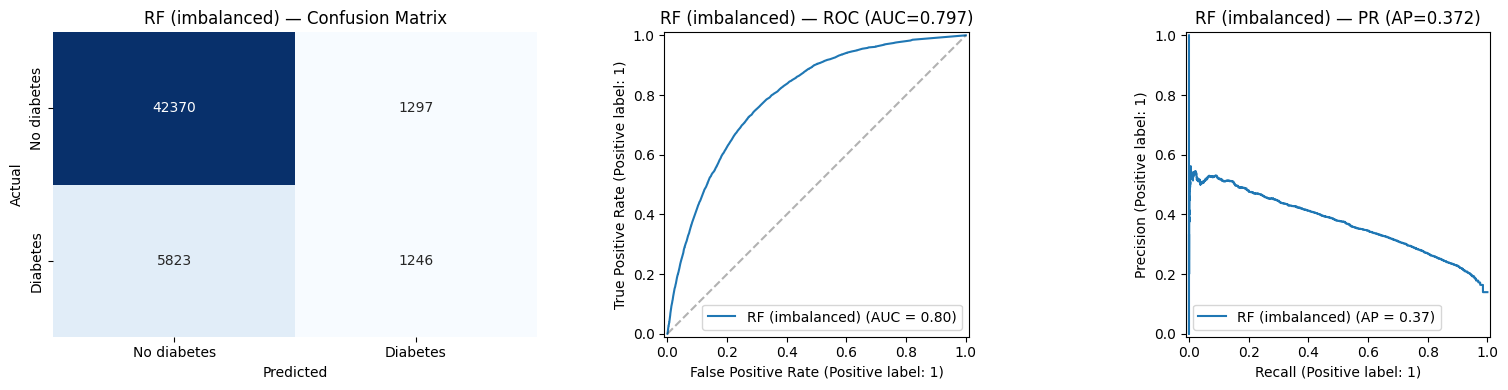

{'accuracy': 0.8596657205928729,
 'precision_0': 0.8791733239267113,
 'recall_0': 0.9702979366569721,
 'f1_0': 0.9224907467885913,
 'precision_1': 0.4899724734565474,
 'recall_1': 0.17626255481680578,
 'f1_1': 0.25925925925925924,
 'macro_f1': 0.5908750030239253,
 'roc_auc': 0.7973837692517649,
 'pr_auc': 0.37210623728905057}

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Track 1 — baseline on the imbalanced training data
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
)
rf_base.fit(X_train_processed, y_train)

evaluate_model(rf_base, X_test_processed, y_test, name='RF (imbalanced)')

===== RF (SMOTE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8854    0.9522    0.9176     43667
   Diabetes (1)     0.4470    0.2385    0.3110      7069

       accuracy                         0.8528     50736
      macro avg     0.6662    0.5954    0.6143     50736
   weighted avg     0.8243    0.8528    0.8331     50736

ROC-AUC: 0.7974   PR-AUC: 0.3655



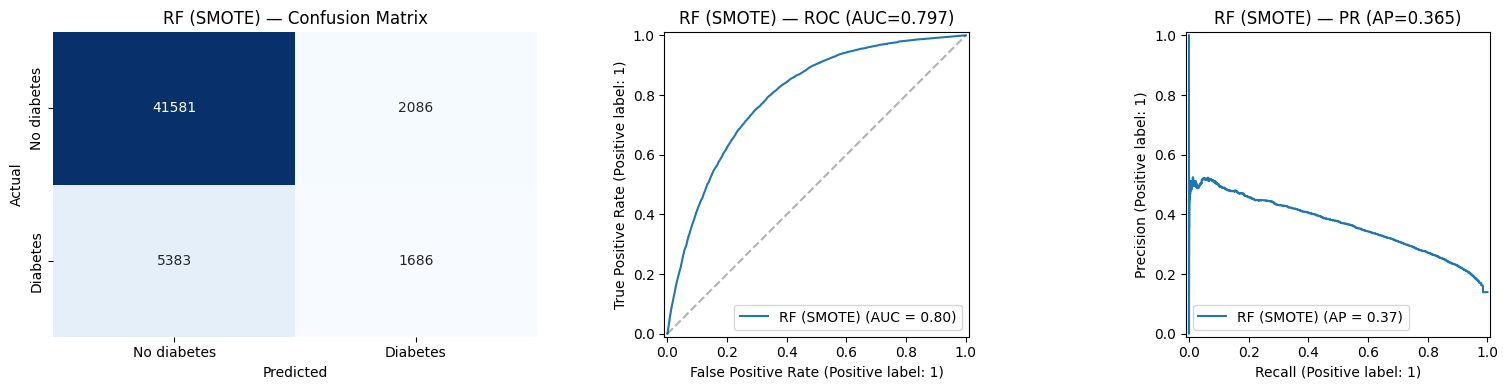

{'accuracy': 0.8527869757174393,
 'precision_0': 0.8853802912869432,
 'recall_0': 0.9522293722948679,
 'f1_0': 0.9175889044587393,
 'precision_1': 0.4469777306468717,
 'recall_1': 0.23850615362851887,
 'f1_1': 0.31104141684346465,
 'macro_f1': 0.6143151606511019,
 'roc_auc': 0.7974338320958847,
 'pr_auc': 0.3654901643396831}

In [ ]:
# Track 2 — SMOTE-balanced training data
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
)
rf_smote.fit(X_train_balanced, y_train_balanced)

evaluate_model(rf_smote, X_test_processed, y_test, name='RF (SMOTE)')

===== RF (class_weight=balanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8767    0.9707    0.9213     43667
   Diabetes (1)     0.4639    0.1565    0.2340      7069

       accuracy                         0.8573     50736
      macro avg     0.6703    0.5636    0.5777     50736
   weighted avg     0.8192    0.8573    0.8255     50736

ROC-AUC: 0.7952   PR-AUC: 0.3593



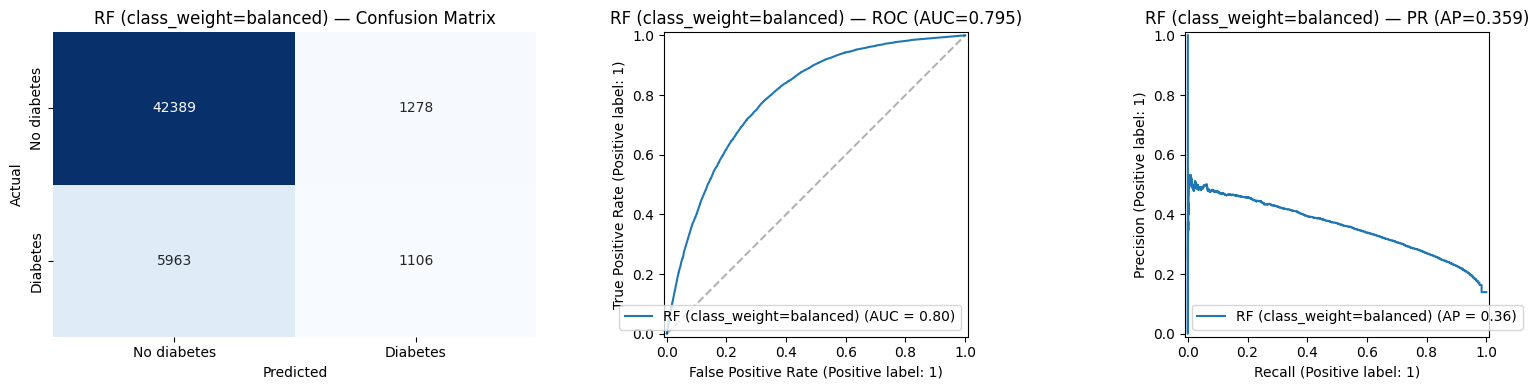

{'accuracy': 0.8572808262377799,
 'precision_0': 0.8766752150893448,
 'recall_0': 0.9707330478393295,
 'f1_0': 0.9213097295123833,
 'precision_1': 0.4639261744966443,
 'recall_1': 0.15645777337671524,
 'f1_1': 0.2339997884269544,
 'macro_f1': 0.5776547589696689,
 'roc_auc': 0.7951887742422888,
 'pr_auc': 0.35932180689807175}

In [ ]:
# Track 3 — class_weight='balanced': reweights per-tree bootstrap samples without resampling
rf_weighted = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf_weighted.fit(X_train_processed, y_train)

evaluate_model(rf_weighted, X_test_processed, y_test, name='RF (class_weight=balanced)')

## XGBoost


===== XGB (imbalanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8791    0.9778    0.9258     43667
   Diabetes (1)     0.5526    0.1693    0.2592      7069

       accuracy                         0.8652     50736
      macro avg     0.7159    0.5736    0.5925     50736
   weighted avg     0.8336    0.8652    0.8330     50736

ROC-AUC: 0.8255   PR-AUC: 0.4188



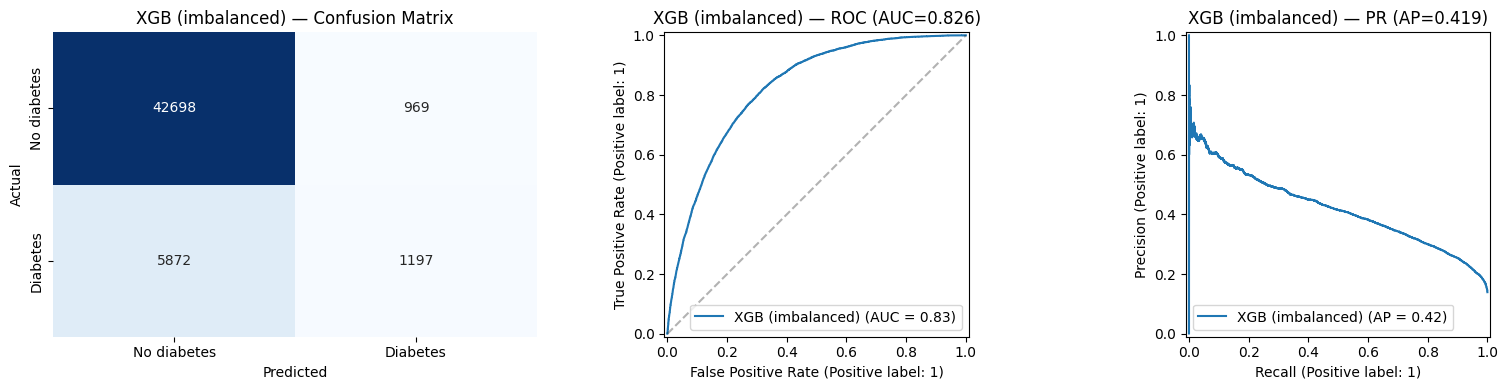

{'accuracy': 0.8651647745190791,
 'precision_0': 0.8791023265390159,
 'recall_0': 0.9778093296997733,
 'f1_0': 0.9258323666207704,
 'precision_1': 0.5526315789473685,
 'recall_1': 0.16933088131277407,
 'f1_1': 0.2592311857065512,
 'macro_f1': 0.5925317761636608,
 'roc_auc': 0.825513225627655,
 'pr_auc': 0.41877090000525047}

In [ ]:
from xgboost import XGBClassifier

# Track 1 — baseline on the imbalanced training data
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
)
xgb_base.fit(X_train_processed, y_train)

evaluate_model(xgb_base, X_test_processed, y_test, name='XGB (imbalanced)')

===== XGB (SMOTE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8817    0.9731    0.9251     43667
   Diabetes (1)     0.5376    0.1932    0.2843      7069

       accuracy                         0.8644     50736
      macro avg     0.7096    0.5832    0.6047     50736
   weighted avg     0.8337    0.8644    0.8358     50736

ROC-AUC: 0.8244   PR-AUC: 0.4202



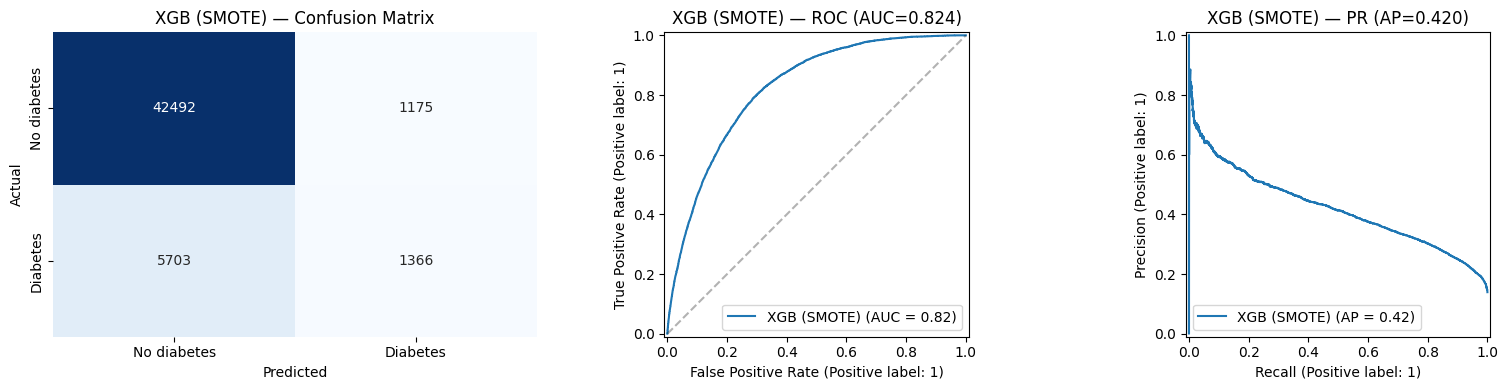

{'accuracy': 0.864435509303059,
 'precision_0': 0.8816682228446935,
 'recall_0': 0.9730918084594774,
 'f1_0': 0.9251268206657813,
 'precision_1': 0.5375836284927195,
 'recall_1': 0.1932380817654548,
 'f1_1': 0.28428720083246617,
 'macro_f1': 0.6047070107491237,
 'roc_auc': 0.824379306338808,
 'pr_auc': 0.42016196239829406}

In [ ]:
# Track 2 — SMOTE-balanced training data
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
)
xgb_smote.fit(X_train_balanced, y_train_balanced)

evaluate_model(xgb_smote, X_test_processed, y_test, name='XGB (SMOTE)')

scale_pos_weight = 174667 / 28277 = 6.1770
===== XGB (scale_pos_weight) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9519    0.7198    0.8197     43667
   Diabetes (1)     0.3093    0.7752    0.4422      7069

       accuracy                         0.7275     50736
      macro avg     0.6306    0.7475    0.6309     50736
   weighted avg     0.8623    0.7275    0.7671     50736

ROC-AUC: 0.8236   PR-AUC: 0.4173



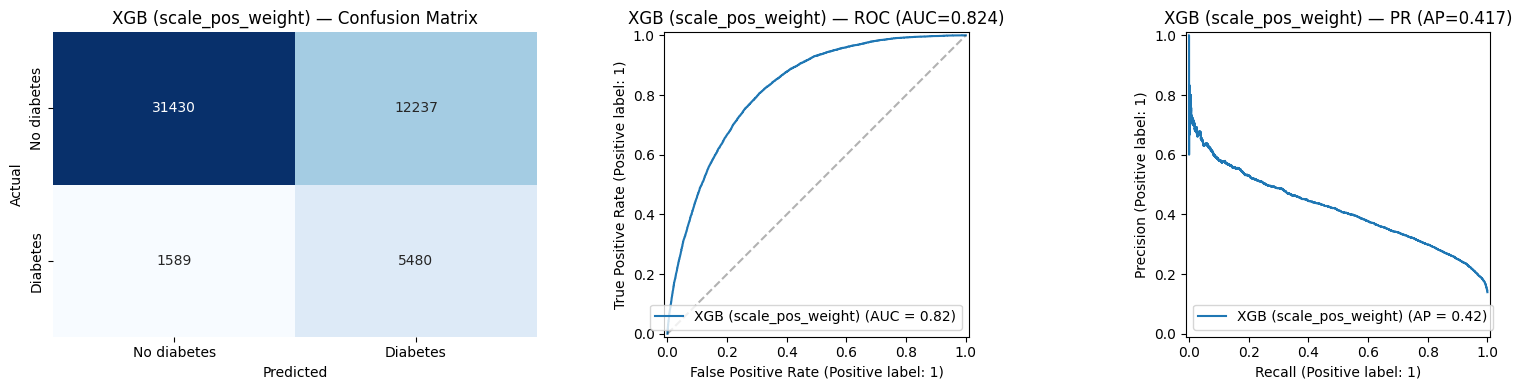

{'accuracy': 0.7274913276568906,
 'precision_0': 0.95187619249523,
 'recall_0': 0.7197654979732979,
 'f1_0': 0.8197063349242365,
 'precision_1': 0.3093074448270023,
 'recall_1': 0.7752157306549724,
 'f1_1': 0.4421851044944727,
 'macro_f1': 0.6309457197093546,
 'roc_auc': 0.8235954916623053,
 'pr_auc': 0.4172922523491201}

In [ ]:
# Track 3 — scale_pos_weight: gradient reweighting (XGBoost's analogue of class_weight='balanced')
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {neg} / {pos} = {spw:.4f}")

xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    scale_pos_weight=spw,
    n_jobs=-1,
    random_state=42,
)
xgb_weighted.fit(X_train_processed, y_train)

evaluate_model(xgb_weighted, X_test_processed, y_test, name='XGB (scale_pos_weight)')

## K-Nearest Neighbors


===== KNN (imbalanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8798    0.9535    0.9152     43667
   Diabetes (1)     0.4050    0.1954    0.2636      7069

       accuracy                         0.8479     50736
      macro avg     0.6424    0.5744    0.5894     50736
   weighted avg     0.8137    0.8479    0.8244     50736

ROC-AUC: 0.7110   PR-AUC: 0.2707



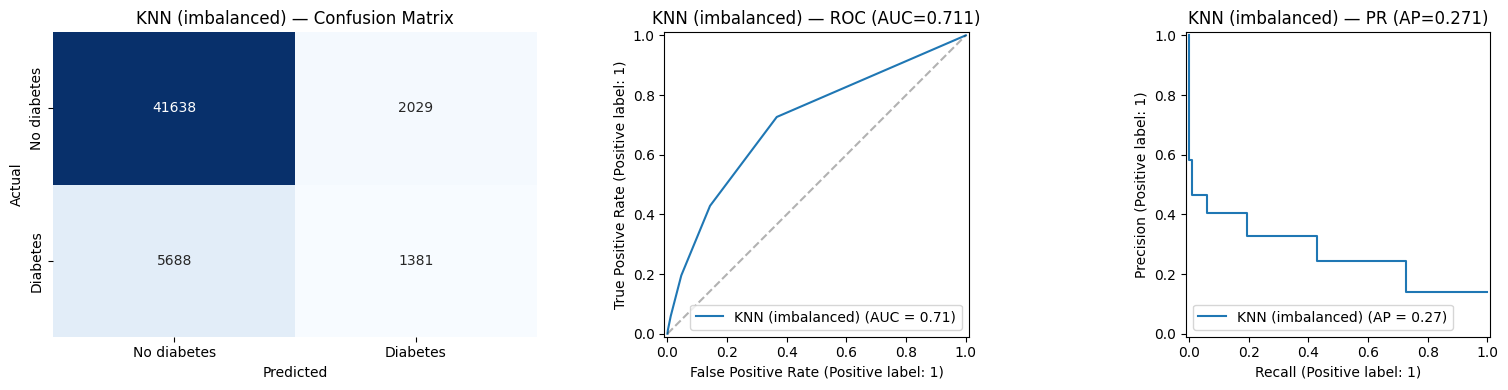

{'accuracy': 0.8478989277830338,
 'precision_0': 0.8798123652960318,
 'recall_0': 0.9535347058419401,
 'f1_0': 0.9151912784499907,
 'precision_1': 0.40498533724340174,
 'recall_1': 0.19536002263403593,
 'f1_1': 0.2635747685847886,
 'macro_f1': 0.5893830235173897,
 'roc_auc': 0.7109573125351716,
 'pr_auc': 0.27070538919281206}

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Track 1 — baseline on the imbalanced training data
knn_base = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_base.fit(X_train_processed, y_train)

evaluate_model(knn_base, X_test_processed, y_test, name='KNN (imbalanced)')

===== KNN (SMOTE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9194    0.7315    0.8147     43667
   Diabetes (1)     0.2668    0.6036    0.3700      7069

       accuracy                         0.7137     50736
      macro avg     0.5931    0.6675    0.5924     50736
   weighted avg     0.8284    0.7137    0.7528     50736

ROC-AUC: 0.7178   PR-AUC: 0.2543



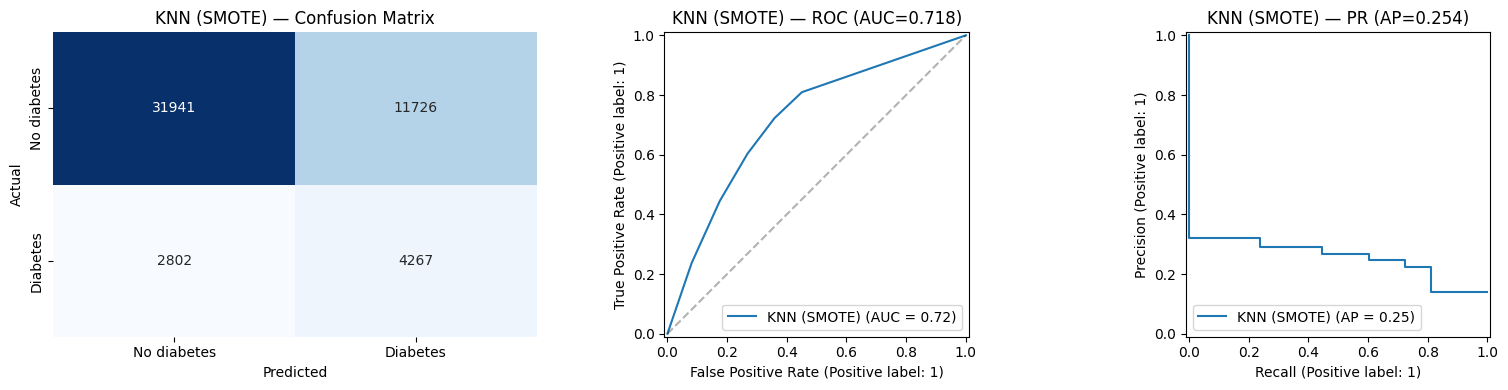

{'accuracy': 0.7136549984232103,
 'precision_0': 0.919350660564718,
 'recall_0': 0.7314676987198571,
 'f1_0': 0.8147175105216171,
 'precision_1': 0.26680422684924654,
 'recall_1': 0.6036214457490451,
 'f1_1': 0.3700459630561096,
 'macro_f1': 0.5923817367888633,
 'roc_auc': 0.7177847574233372,
 'pr_auc': 0.25428323697110555}

In [ ]:
# Track 2 — SMOTE-balanced training data
knn_smote = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_smote.fit(X_train_balanced, y_train_balanced)

evaluate_model(knn_smote, X_test_processed, y_test, name='KNN (SMOTE)')

# Hyperparameter Tuning


In [ ]:
def tune_and_evaluate(search, X_train, y_train, X_test, y_test, name, top_n=5):
    """Fit a scikit-learn *SearchCV object, report the winner, then test-evaluate it.

    Works with any sklearn-compatible search — GridSearchCV, RandomizedSearchCV,
    HalvingGridSearchCV, HalvingRandomSearchCV — so long as it exposes
    .fit, .best_params_, .best_score_, .best_estimator_, and .cv_results_.

    The search object encodes the *strategy* (which grid, which CV, which metric);
    this helper handles the *plumbing* that is identical for every model:
      1. run the search on the training set
      2. print best CV score + params
      3. display top-N CV configs so alternatives are visible
      4. hand the refit best_estimator_ to evaluate_model() for test-set eval,
         plots, and registration in the global `results` dict
    """
    print(f"===== Tuning: {name} =====")
    search.fit(X_train, y_train)

    print(f"\nBest CV score ({search.scoring}): {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}\n")

    # Top-N CV configs — so we can see what was close to the best
    cv_df = pd.DataFrame(search.cv_results_)
    cols = ['mean_test_score', 'std_test_score', 'params']
    print(f"Top {top_n} configs by mean CV score:")
    display(cv_df.sort_values('mean_test_score', ascending=False).head(top_n)[cols])

    # Evaluate the refit best estimator on the untouched test set.
    # Result gets registered in `results` automatically by evaluate_model.
    return evaluate_model(search.best_estimator_, X_test, y_test, name=name)

## Logistic Regression — tuned with SMOTE inside CV


===== Tuning: LR (tuned, SMOTE in CV) =====


Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best CV score (average_precision): 0.4039
Best params: {'clf__C': 0.01, 'smote__k_neighbors': 5}

Top 5 configs by mean CV score:


,mean_test_score,std_test_score,params
1,0.403896,0.004783,"{'clf__C': 0.01, 'smote__k_neighbors': 5}"
2,0.403718,0.004812,"{'clf__C': 0.01, 'smote__k_neighbors': 7}"
0,0.403688,0.004642,"{'clf__C': 0.01, 'smote__k_neighbors': 3}"
4,0.403584,0.004846,"{'clf__C': 0.1, 'smote__k_neighbors': 5}"
7,0.403521,0.004869,"{'clf__C': 1, 'smote__k_neighbors': 5}"


===== LR (tuned, SMOTE in CV) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9495    0.7283    0.8243     43667
   Diabetes (1)     0.3119    0.7606    0.4424      7069

       accuracy                         0.7328     50736
      macro avg     0.6307    0.7445    0.6333     50736
   weighted avg     0.8606    0.7328    0.7711     50736

ROC-AUC: 0.8179   PR-AUC: 0.3897



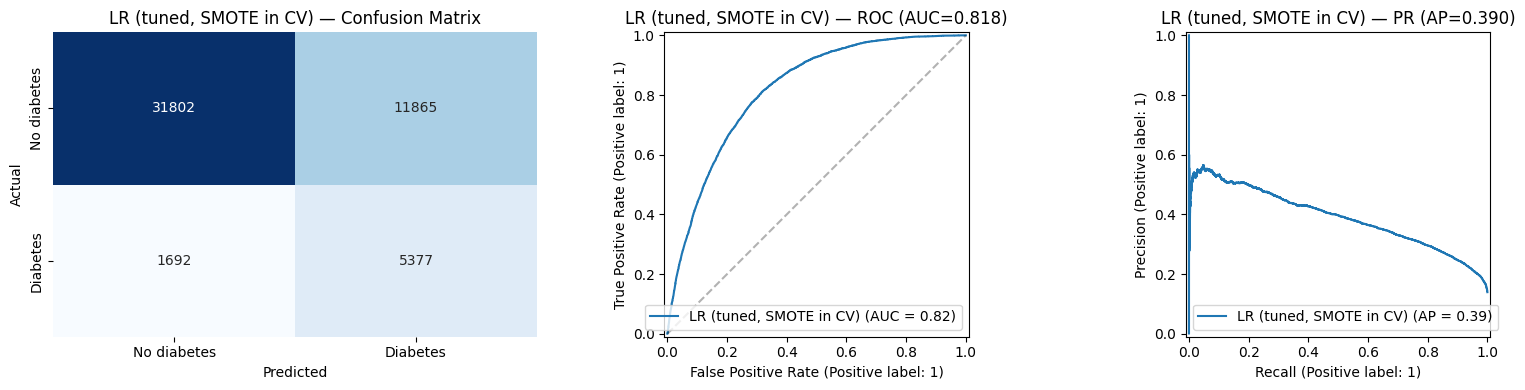

{'accuracy': 0.7327932828760644,
 'precision_0': 0.9494834895802233,
 'recall_0': 0.7282845169120846,
 'f1_0': 0.8243024325760423,
 'precision_1': 0.3118547732281638,
 'recall_1': 0.7606450700240487,
 'f1_1': 0.4423511990456995,
 'macro_f1': 0.6333268158108709,
 'roc_auc': 0.8178774181481894,
 'pr_auc': 0.38965831247217225}

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

lr_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42)),
])

lr_param_grid = {
    'clf__C':             [0.01, 0.1, 1, 10, 100],   # regularization strength
    'smote__k_neighbors': [3, 5, 7],                 # SMOTE's neighborhood size
}

# Shared CV splitter — reused by the KNN tuning cell below for a fair comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_search = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='average_precision',   # PR-AUC — better than ROC-AUC on imbalanced data
    refit=True,                    # retrain best config on ALL of X_train before predict
    n_jobs=-1,
    verbose=1,
)

# 5 C × 3 k_neighbors × 5 folds = 75 fits
tune_and_evaluate(
    lr_search,
    X_train_processed, y_train,
    X_test_processed,  y_test,
    name='LR (tuned, SMOTE in CV)',
)

## KNN — tuned with `HalvingRandomSearchCV`


===== Tuning: KNN (tuned) =====
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 6
min_resources_: 500
max_resources_: 202944
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 500
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 1
n_candidates: 7
n_resources: 1500
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 2
n_candidates: 3
n_resources: 4500
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best CV score (average_precision): 0.3740
Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 51}

Top 5 configs by mean CV score:


,mean_test_score,std_test_score,params
29,0.373979,0.034547,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
28,0.358483,0.031601,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
7,0.353739,0.142244,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
24,0.349540,0.083821,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
27,0.337878,0.036533,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."


===== KNN (tuned) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8704    0.9864    0.9248     43667
   Diabetes (1)     0.5249    0.0925    0.1573      7069

       accuracy                         0.8619     50736
      macro avg     0.6976    0.5395    0.5410     50736
   weighted avg     0.8222    0.8619    0.8179     50736

ROC-AUC: 0.7887   PR-AUC: 0.3577



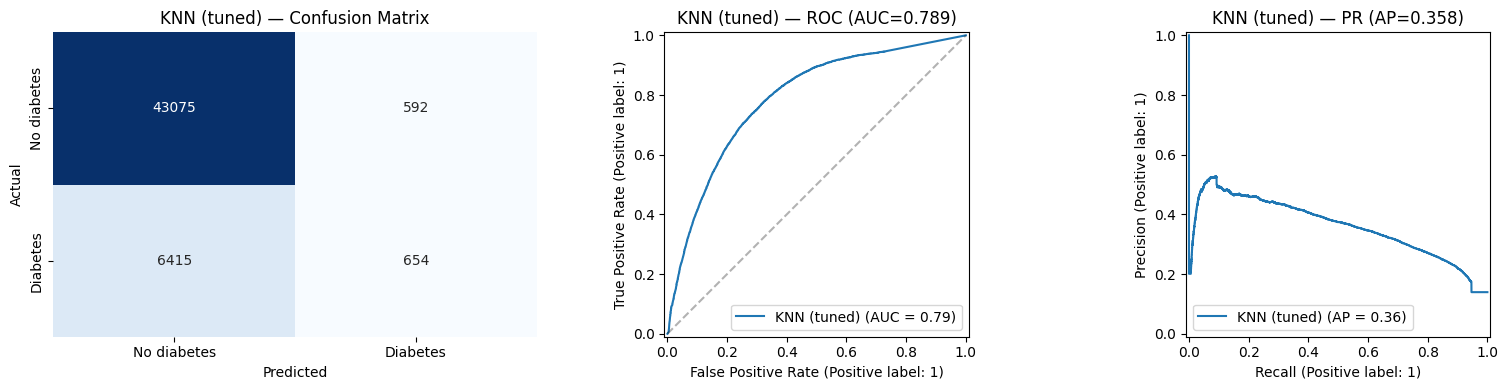

{'accuracy': 0.86189293598234,
 'precision_0': 0.8703778541119418,
 'recall_0': 0.9864428515812856,
 'f1_0': 0.9247828933950213,
 'precision_1': 0.5248796147672552,
 'recall_1': 0.09251662187013722,
 'f1_1': 0.15730607336139507,
 'macro_f1': 0.5410444833782082,
 'roc_auc': 0.788709418947925,
 'pr_auc': 0.3576837050640715}

In [ ]:
# HalvingRandomSearchCV is still experimental — this import flips the switch
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

# Search space — discrete values sampled at random by halving
knn_param_dist = {
    'n_neighbors': [3, 5, 7, 11, 15, 21, 31, 51],
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2],                       # 1 = Manhattan, 2 = Euclidean
}

# Halving search:
#   - resource='n_samples'  → the growing "budget" each round is training-set size
#   - factor=3              → keep top 1/3 of candidates each round
#   - n_candidates=20       → start with 20 random configs (of 32 possible)
#   - min_resources=500     → floor for the first round. Must be large enough
#                             that after a 5-fold split, each train fold still
#                             has more samples than the largest n_neighbors (51).
#                             With 500 samples * 4/5 = 400 train rows per fold,
#                             even n_neighbors=51 fits. The default 'exhaust'
#                             starts too small and causes predict_proba to fail
#                             (insufficient neighbors) → nan scores in round 1.
knn_search = HalvingRandomSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_distributions=knn_param_dist,
    n_candidates=20,
    factor=3,
    resource='n_samples',
    min_resources=500,
    cv=cv,                         # reuse the StratifiedKFold from the LR cell
    scoring='average_precision',
    refit=True,                    # refit best config on ALL of X_train before predict
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

# Tuning runs on the imbalanced training set (no SMOTE here — see markdown above)
tune_and_evaluate(
    knn_search,
    X_train_processed, y_train,
    X_test_processed,  y_test,
    name='KNN (tuned)',
)

## Random Forest — tuned with `HalvingRandomSearchCV`


===== Tuning: RF (tuned) =====
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 6
min_resources_: 500
max_resources_: 202944
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 500
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 1
n_candidates: 7
n_resources: 1500
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 2
n_candidates: 3
n_resources: 4500
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best CV score (average_precision): 0.4260
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}

Top 5 configs by mean CV score:


,mean_test_score,std_test_score,params
29,0.425996,0.035186,"{'n_estimators': 200, 'min_samples_split': 2, ..."
28,0.425996,0.035186,"{'n_estimators': 200, 'min_samples_split': 5, ..."
27,0.421887,0.039260,"{'n_estimators': 200, 'min_samples_split': 5, ..."
14,0.390235,0.135870,"{'n_estimators': 200, 'min_samples_split': 5, ..."
13,0.389821,0.127282,"{'n_estimators': 400, 'min_samples_split': 2, ..."


===== RF (tuned) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8705    0.9899    0.9264     43667
   Diabetes (1)     0.5910    0.0905    0.1570      7069

       accuracy                         0.8646     50736
      macro avg     0.7307    0.5402    0.5417     50736
   weighted avg     0.8316    0.8646    0.8192     50736

ROC-AUC: 0.8221   PR-AUC: 0.4171



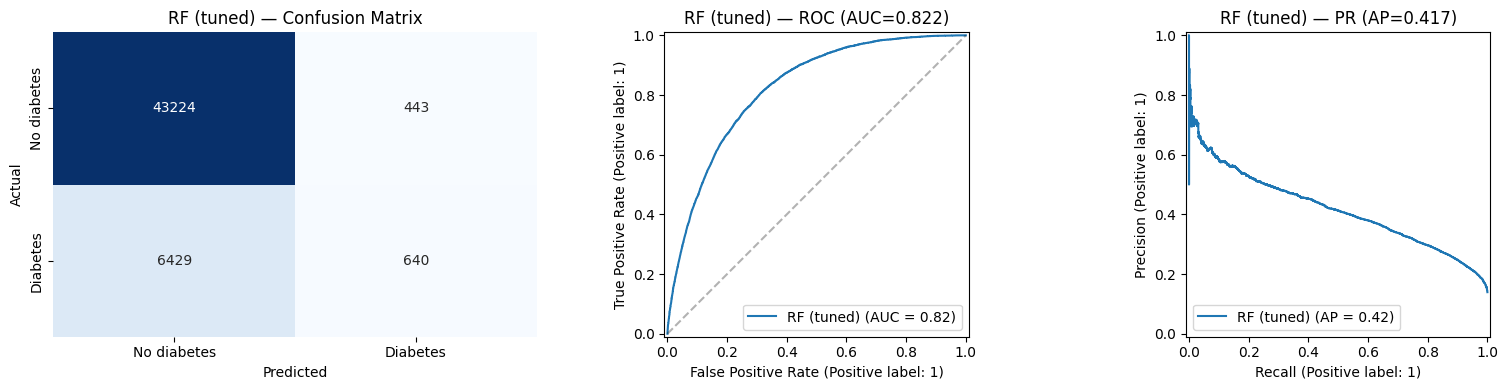

{'accuracy': 0.8645537685272785,
 'precision_0': 0.8705214186453991,
 'recall_0': 0.9898550392745094,
 'f1_0': 0.926360908701243,
 'precision_1': 0.5909510618651893,
 'recall_1': 0.09053614372612817,
 'f1_1': 0.15701668302257116,
 'macro_f1': 0.5416887958619071,
 'roc_auc': 0.8220854069626206,
 'pr_auc': 0.4170727884874656}

In [ ]:
rf_param_dist = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [None, 10, 20, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      [None, 'balanced'],
}
# Total: 3 * 4 * 3 * 3 * 2 * 2 = 432 possible configs — halving samples 20 at the start.

rf_search = HalvingRandomSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
    param_distributions=rf_param_dist,
    n_candidates=20,
    factor=3,
    resource='n_samples',
    min_resources=500,
    cv=cv,
    scoring='average_precision',
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

tune_and_evaluate(
    rf_search,
    X_train_processed, y_train,
    X_test_processed,  y_test,
    name='RF (tuned)',
)

## XGBoost — tuned with `HalvingRandomSearchCV`


===== Tuning: XGB (tuned) =====
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 500
max_resources_: 202944
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 30
n_resources: 500
Fitting 5 folds for each of 30 candidates, totalling 150 fits
----------
iter: 1
n_candidates: 10
n_resources: 1500
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 2
n_candidates: 4
n_resources: 4500
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 3
n_candidates: 2
n_resources: 13500
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best CV score (average_precision): 0.4139
Best params: {'subsample': 1.0, 'scale_pos_weight': np.float64(6.176998974431517), 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Top 5 configs by mean CV score:


,mean_test_score,std_test_score,params
42,0.440952,0.042379,"{'subsample': 1.0, 'scale_pos_weight': 6.17699..."
43,0.435845,0.036495,"{'subsample': 0.7, 'scale_pos_weight': 1, 'reg..."
40,0.434149,0.043648,"{'subsample': 1.0, 'scale_pos_weight': 1, 'reg..."
41,0.434142,0.039390,"{'subsample': 1.0, 'scale_pos_weight': 1, 'reg..."
45,0.413920,0.015222,"{'subsample': 1.0, 'scale_pos_weight': 6.17699..."


===== XGB (tuned) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9544    0.7067    0.8121     43667
   Diabetes (1)     0.3040    0.7913    0.4393      7069

       accuracy                         0.7185     50736
      macro avg     0.6292    0.7490    0.6257     50736
   weighted avg     0.8638    0.7185    0.7602     50736

ROC-AUC: 0.8248   PR-AUC: 0.4178



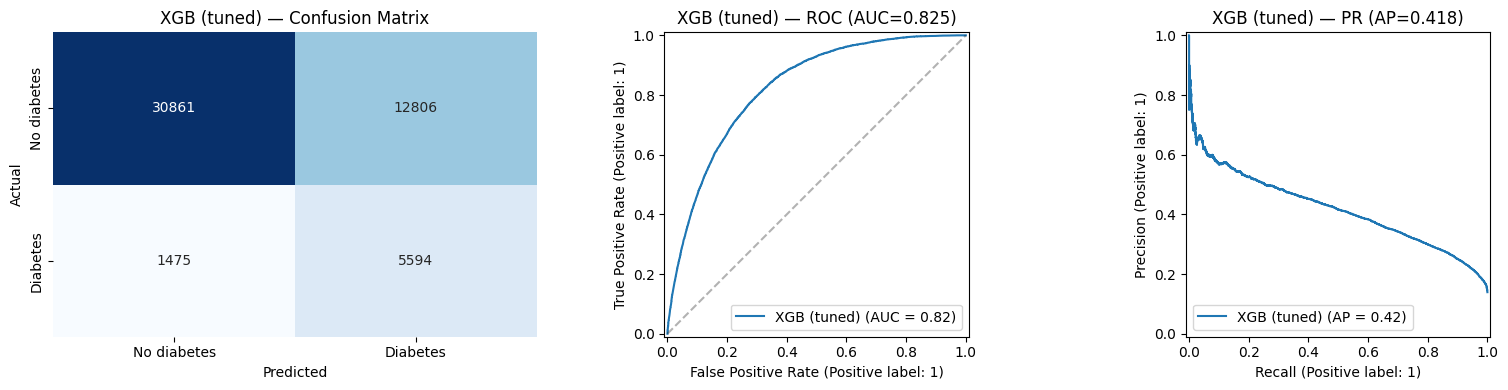

{'accuracy': 0.7185233364869127,
 'precision_0': 0.9543852053438892,
 'recall_0': 0.7067350630911214,
 'f1_0': 0.8120995223872742,
 'precision_1': 0.3040217391304348,
 'recall_1': 0.791342481256189,
 'f1_1': 0.43927912364050414,
 'macro_f1': 0.6256893230138891,
 'roc_auc': 0.8248216466431542,
 'pr_auc': 0.41779850945178654}

In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

xgb_param_dist = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [3, 6, 9],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_weight': [1, 5],
    'reg_lambda':       [1.0, 5.0],
    'scale_pos_weight': [1, spw],
}
# Total: 3*3*3*2*2*2*2*2 = 864 possible configs — halving samples 30 at the start.

xgb_search = HalvingRandomSearchCV(
    estimator=XGBClassifier(
        tree_method='hist',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42,
    ),
    param_distributions=xgb_param_dist,
    n_candidates=30,
    factor=3,
    resource='n_samples',
    min_resources=500,
    cv=cv,
    scoring='average_precision',
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

tune_and_evaluate(
    xgb_search,
    X_train_processed, y_train,
    X_test_processed,  y_test,
    name='XGB (tuned)',
)

# Multi-Layer Perceptron (Neural Network)


===== MLP (imbalanced) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8784    0.9775    0.9253     43667
   Diabetes (1)     0.5416    0.1640    0.2517      7069

       accuracy                         0.8642     50736
      macro avg     0.7100    0.5707    0.5885     50736
   weighted avg     0.8315    0.8642    0.8315     50736

ROC-AUC: 0.8253   PR-AUC: 0.4211



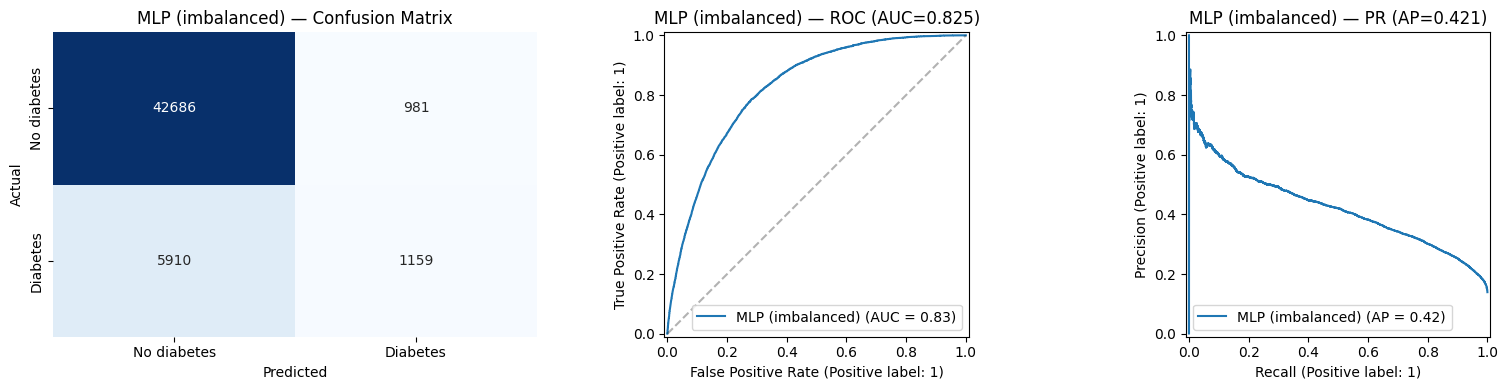

{'accuracy': 0.8641792809839167,
 'precision_0': 0.8783850522676764,
 'recall_0': 0.9775345226372317,
 'f1_0': 0.9253113382395977,
 'precision_1': 0.541588785046729,
 'recall_1': 0.16395529777903523,
 'f1_1': 0.2517102834183951,
 'macro_f1': 0.5885108108289964,
 'roc_auc': 0.8253147641189329,
 'pr_auc': 0.42114288132448824}

In [ ]:
from sklearn.neural_network import MLPClassifier

# Track 1 — baseline on the imbalanced training data
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # two hidden layers: 128 -> 64
    activation='relu',
    solver='adam',
    alpha=0.0001,                    # L2 regularization
    early_stopping=True,             # hold out val set, stop when loss plateaus
    validation_fraction=0.1,         # 10% of train becomes internal validation
    n_iter_no_change=10,             # patience — stop after 10 stagnant epochs
    max_iter=500,                    # safety cap; early stopping usually triggers first
    random_state=42,
    verbose=False,                   # set to True to see per-epoch loss
)
mlp_base.fit(X_train_processed, y_train)

evaluate_model(mlp_base, X_test_processed, y_test, name='MLP (imbalanced)')

===== MLP (SMOTE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9135    0.8472    0.8791     43667
   Diabetes (1)     0.3484    0.5047    0.4122      7069

       accuracy                         0.7995     50736
      macro avg     0.6310    0.6760    0.6457     50736
   weighted avg     0.8348    0.7995    0.8141     50736

ROC-AUC: 0.7846   PR-AUC: 0.3483



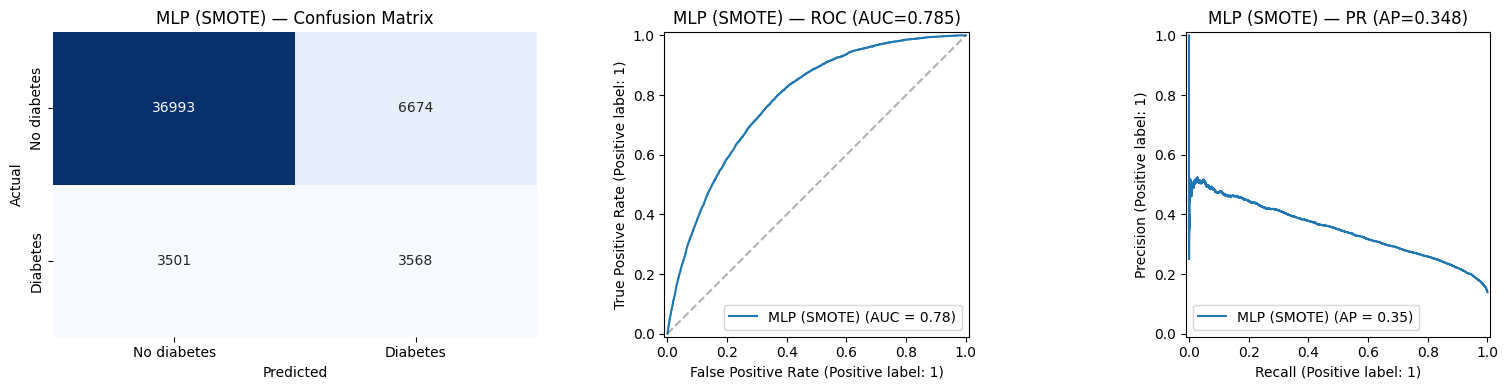

{'accuracy': 0.7994520655944497,
 'precision_0': 0.9135427470736406,
 'recall_0': 0.8471614720498317,
 'f1_0': 0.8791007711410274,
 'precision_1': 0.3483694590900215,
 'recall_1': 0.5047390012731645,
 'f1_1': 0.4122234417422448,
 'macro_f1': 0.6456621064416361,
 'roc_auc': 0.7846493380017793,
 'pr_auc': 0.3482505893774425}

In [ ]:
# Track 2 — SMOTE-balanced training data
mlp_smote = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    max_iter=500,
    random_state=42,
    verbose=False,
)
mlp_smote.fit(X_train_balanced, y_train_balanced)

evaluate_model(mlp_smote, X_test_processed, y_test, name='MLP (SMOTE)')

## MLP — tuned with `HalvingRandomSearchCV`


===== Tuning: MLP (tuned) =====
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 6
min_resources_: 500
max_resources_: 202944
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 500
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 1
n_candidates: 7
n_resources: 1500
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 2
n_candidates: 3
n_resources: 4500
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best CV score (average_precision): 0.3959
Best params: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (128,), 'batch_size': 256, 'alpha': 0.001}

Top 5 configs by mean CV score:


,mean_test_score,std_test_score,params
29,0.395850,0.032418,"{'learning_rate_init': 0.01, 'hidden_layer_siz..."
28,0.384341,0.037440,"{'learning_rate_init': 0.01, 'hidden_layer_siz..."
27,0.373541,0.023394,"{'learning_rate_init': 0.001, 'hidden_layer_si..."
26,0.332396,0.070561,"{'learning_rate_init': 0.01, 'hidden_layer_siz..."
22,0.330861,0.058951,"{'learning_rate_init': 0.01, 'hidden_layer_siz..."


===== MLP (tuned) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8740    0.9859    0.9265     43667
   Diabetes (1)     0.5823    0.1217    0.2013      7069

       accuracy                         0.8655     50736
      macro avg     0.7281    0.5538    0.5639     50736
   weighted avg     0.8333    0.8655    0.8255     50736

ROC-AUC: 0.8257   PR-AUC: 0.4167



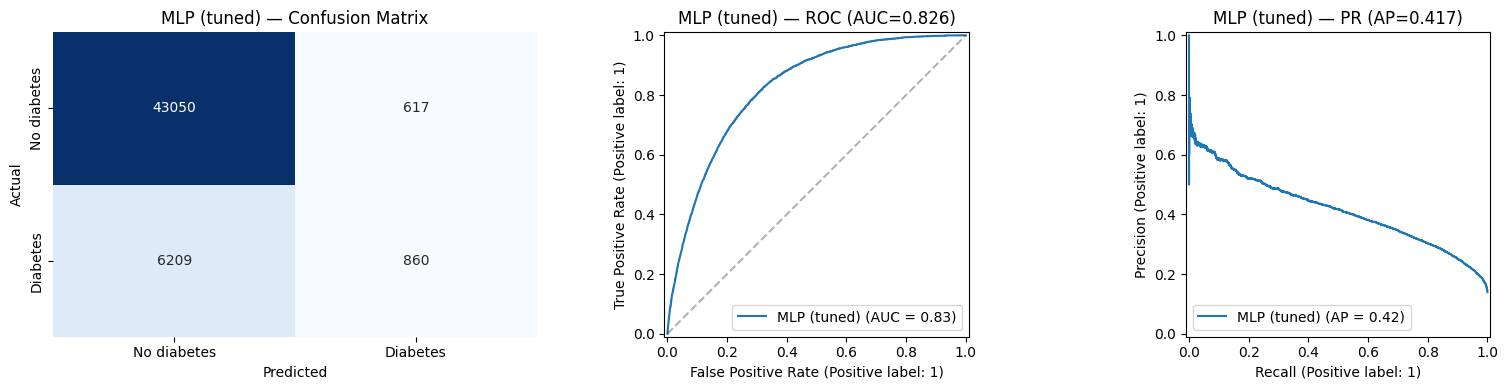

{'accuracy': 0.8654604225796279,
 'precision_0': 0.8739519681682535,
 'recall_0': 0.9858703368676575,
 'f1_0': 0.9265437014398553,
 'precision_1': 0.5822613405551794,
 'recall_1': 0.12165794313198472,
 'f1_1': 0.20126374912239645,
 'macro_f1': 0.5639037252811259,
 'roc_auc': 0.8256663556983362,
 'pr_auc': 0.4167451355438997}

In [ ]:
# Reuses `cv` (StratifiedKFold from cell 46) and HalvingRandomSearchCV (imported in cell 48).

mlp_param_dist = {
    'hidden_layer_sizes':  [(64,), (128,), (64, 32), (128, 64), (256, 128)],
    'alpha':               [1e-5, 1e-4, 1e-3, 1e-2],       # L2 regularization
    'learning_rate_init':  [1e-4, 1e-3, 1e-2],             # Adam's initial LR
    'batch_size':          [64, 128, 256],
}
# Total: 5 * 4 * 3 * 3 = 180 possible configs — halving samples 20 at the start.

mlp_search = HalvingRandomSearchCV(
    estimator=MLPClassifier(
        activation='relu',
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        max_iter=500,
        random_state=42,
    ),
    param_distributions=mlp_param_dist,
    n_candidates=20,
    factor=3,
    resource='n_samples',
    min_resources=500,              # same safety floor as KNN tuning
    cv=cv,                          # reuse StratifiedKFold from LR tuning
    scoring='average_precision',
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

# Tuning runs on the imbalanced training set (see markdown above)
tune_and_evaluate(
    mlp_search,
    X_train_processed, y_train,
    X_test_processed,  y_test,
    name='MLP (tuned)',
)

# Feature Engineering Ablation


===== LR (class_weight=balanced, +FE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9502    0.7279    0.8243     43667
   Diabetes (1)     0.3125    0.7642    0.4436      7069

       accuracy                         0.7329     50736
      macro avg     0.6313    0.7460    0.6340     50736
   weighted avg     0.8613    0.7329    0.7713     50736

ROC-AUC: 0.8209   PR-AUC: 0.4011



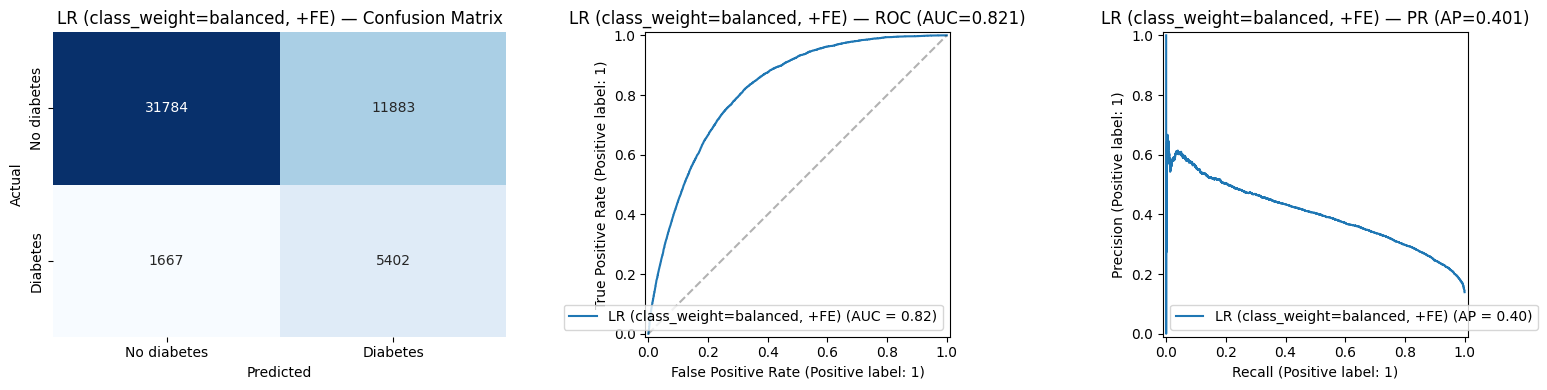

{'accuracy': 0.7329312519709871,
 'precision_0': 0.9501659143224418,
 'recall_0': 0.7278723063182724,
 'f1_0': 0.8242952358722996,
 'precision_1': 0.31252531096326297,
 'recall_1': 0.7641816381383505,
 'f1_1': 0.443623224111029,
 'macro_f1': 0.6339592299916643,
 'roc_auc': 0.82093764171035,
 'pr_auc': 0.4011076825405512}

In [ ]:
# LR (class_weight=balanced) — engineered features
lr_weighted_fe = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_weighted_fe.fit(X_train_processed_fe, y_train)

evaluate_model(lr_weighted_fe, X_test_processed_fe, y_test,
               name='LR (class_weight=balanced, +FE)')

===== MLP (imbalanced, +FE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.8782    0.9784    0.9256     43667
   Diabetes (1)     0.5479    0.1617    0.2497      7069

       accuracy                         0.8646     50736
      macro avg     0.7131    0.5700    0.5876     50736
   weighted avg     0.8322    0.8646    0.8314     50736

ROC-AUC: 0.8254   PR-AUC: 0.4200



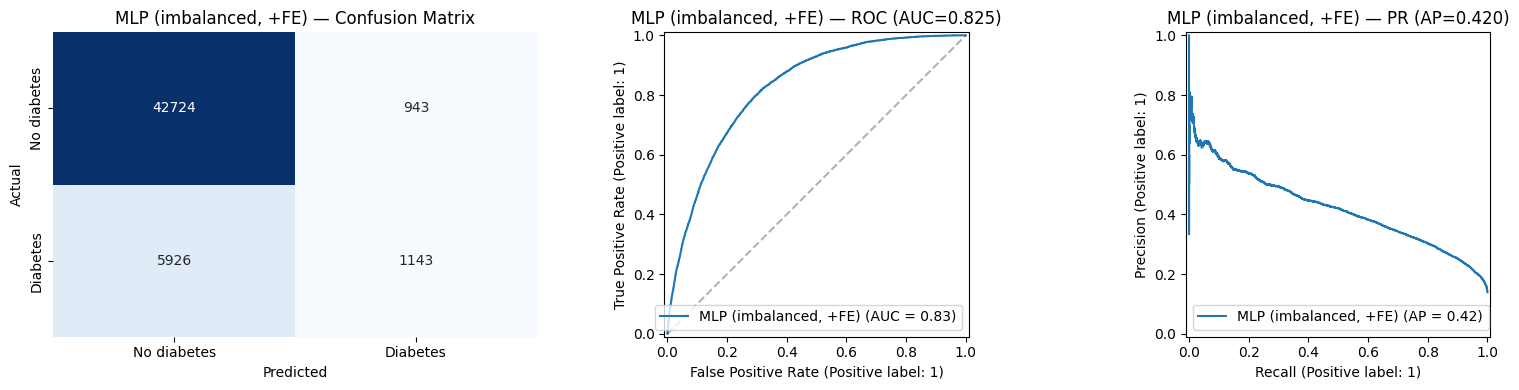

{'accuracy': 0.8646128981393882,
 'precision_0': 0.878191161356629,
 'recall_0': 0.9784047450019465,
 'f1_0': 0.9255933360052861,
 'precision_1': 0.5479386385426653,
 'recall_1': 0.161691894185882,
 'f1_1': 0.2496996176952485,
 'macro_f1': 0.5876464768502674,
 'roc_auc': 0.8254328208805345,
 'pr_auc': 0.4200239706350072}

In [ ]:
# MLP (imbalanced) — engineered features
mlp_base_fe = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    max_iter=500,
    random_state=42,
    verbose=False,
)
mlp_base_fe.fit(X_train_processed_fe, y_train)

evaluate_model(mlp_base_fe, X_test_processed_fe, y_test,
               name='MLP (imbalanced, +FE)')

===== Tuning: XGB (tuned, +FE) =====
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 500
max_resources_: 202944
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 30
n_resources: 500
Fitting 5 folds for each of 30 candidates, totalling 150 fits
----------
iter: 1
n_candidates: 10
n_resources: 1500
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 2
n_candidates: 4
n_resources: 4500
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 3
n_candidates: 2
n_resources: 13500
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best CV score (average_precision): 0.4146
Best params: {'subsample': 1.0, 'scale_pos_weight': np.float64(6.176998974431517), 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Top 5 configs by mean CV score:


,mean_test_score,std_test_score,params
40,0.432478,0.049805,"{'subsample': 1.0, 'scale_pos_weight': 6.17699..."
43,0.425703,0.043615,"{'subsample': 0.7, 'scale_pos_weight': 1, 'reg..."
42,0.423415,0.044170,"{'subsample': 1.0, 'scale_pos_weight': 1, 'reg..."
41,0.419227,0.052452,"{'subsample': 0.7, 'scale_pos_weight': 6.17699..."
45,0.414626,0.015018,"{'subsample': 1.0, 'scale_pos_weight': 6.17699..."


===== XGB (tuned, +FE) =====
                 precision    recall  f1-score   support

No diabetes (0)     0.9546    0.7049    0.8110     43667
   Diabetes (1)     0.3031    0.7929    0.4386      7069

       accuracy                         0.7172     50736
      macro avg     0.6289    0.7489    0.6248     50736
   weighted avg     0.8638    0.7172    0.7591     50736

ROC-AUC: 0.8241   PR-AUC: 0.4159



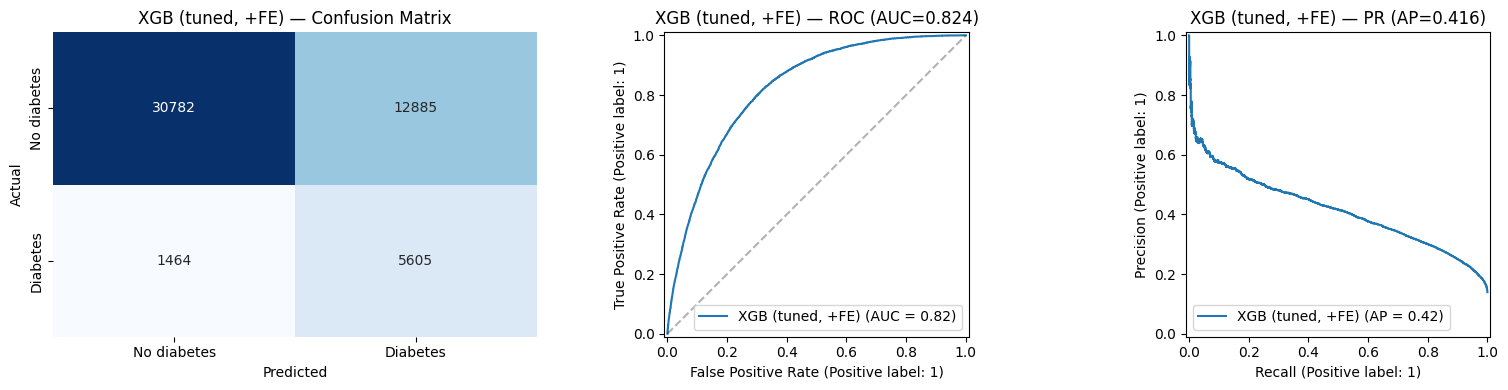

{'accuracy': 0.7171830652790918,
 'precision_0': 0.9545990200334925,
 'recall_0': 0.7049259165960565,
 'f1_0': 0.8109809913980478,
 'precision_1': 0.30313683071930775,
 'recall_1': 0.7928985712264818,
 'f1_1': 0.4385930591963692,
 'macro_f1': 0.6247870252972085,
 'roc_auc': 0.8241075979342016,
 'pr_auc': 0.41589968359412627}

In [ ]:
# XGB (tuned) — engineered features. Same search space as cell 67.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

xgb_param_dist_fe = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [3, 6, 9],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_weight': [1, 5],
    'reg_lambda':       [1.0, 5.0],
    'scale_pos_weight': [1, spw],
}

xgb_search_fe = HalvingRandomSearchCV(
    estimator=XGBClassifier(
        tree_method='hist',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42,
    ),
    param_distributions=xgb_param_dist_fe,
    n_candidates=30,
    factor=3,
    resource='n_samples',
    min_resources=500,
    cv=cv,
    scoring='average_precision',
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

tune_and_evaluate(
    xgb_search_fe,
    X_train_processed_fe, y_train,
    X_test_processed_fe,  y_test,
    name='XGB (tuned, +FE)',
)

# Final Model Comparison


All models ranked by PR-AUC:



,model,strategy,accuracy,precision_1,recall_1,f1_1,macro_f1,roc_auc,pr_auc
MLP (imbalanced),MLP,baseline,0.8642,0.5416,0.1640,0.2517,0.5885,0.8253,0.4211
XGB (SMOTE),XGBoost,SMOTE,0.8644,0.5376,0.1932,0.2843,0.6047,0.8244,0.4202
"MLP (imbalanced, +FE)",MLP,baseline,0.8646,0.5479,0.1617,0.2497,0.5876,0.8254,0.4200
XGB (imbalanced),XGBoost,baseline,0.8652,0.5526,0.1693,0.2592,0.5925,0.8255,0.4188
XGB (tuned),XGBoost,tuned,0.7185,0.3040,0.7913,0.4393,0.6257,0.8248,0.4178
XGB (scale_pos_weight),XGBoost,reweighted,0.7275,0.3093,0.7752,0.4422,0.6309,0.8236,0.4173
RF (tuned),Random Forest,tuned,0.8646,0.5910,0.0905,0.1570,0.5417,0.8221,0.4171
MLP (tuned),MLP,tuned,0.8655,0.5823,0.1217,0.2013,0.5639,0.8257,0.4167
"XGB (tuned, +FE)",XGBoost,tuned,0.7172,0.3031,0.7929,0.4386,0.6248,0.8241,0.4159
"LR (class_weight=balanced, +FE)",Logistic Regression,reweighted,0.7329,0.3125,0.7642,0.4436,0.6340,0.8209,0.4011


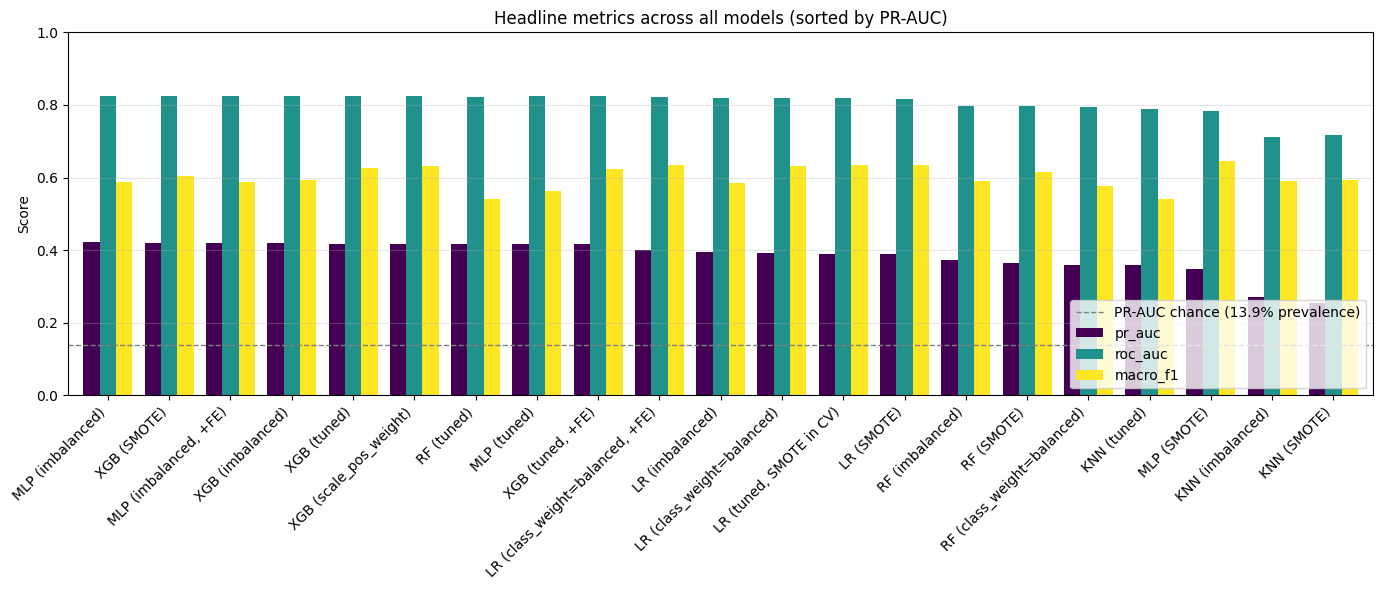

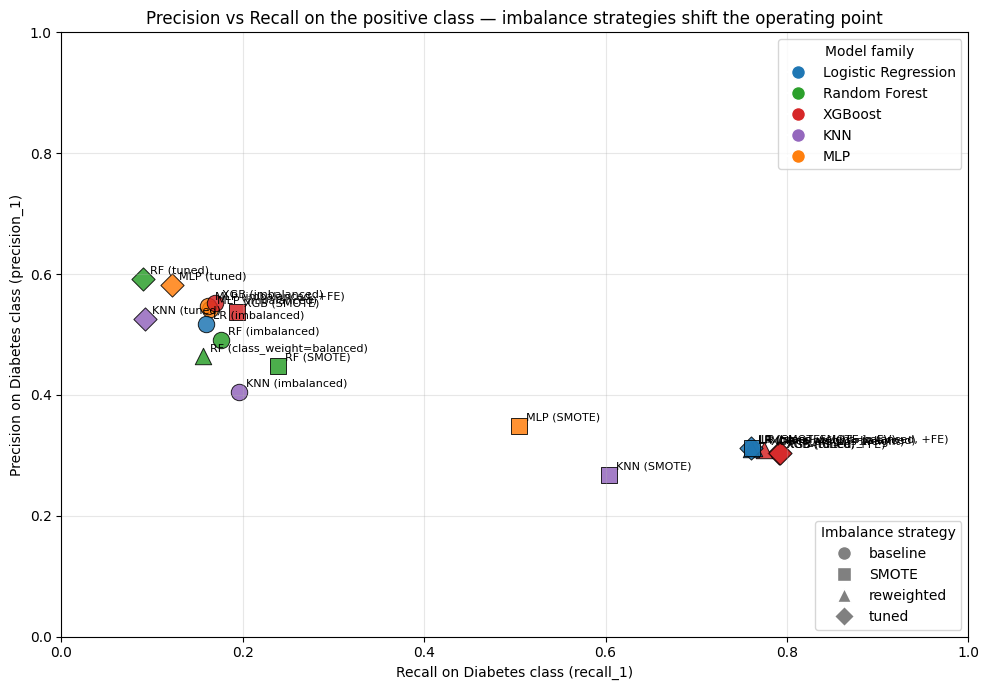

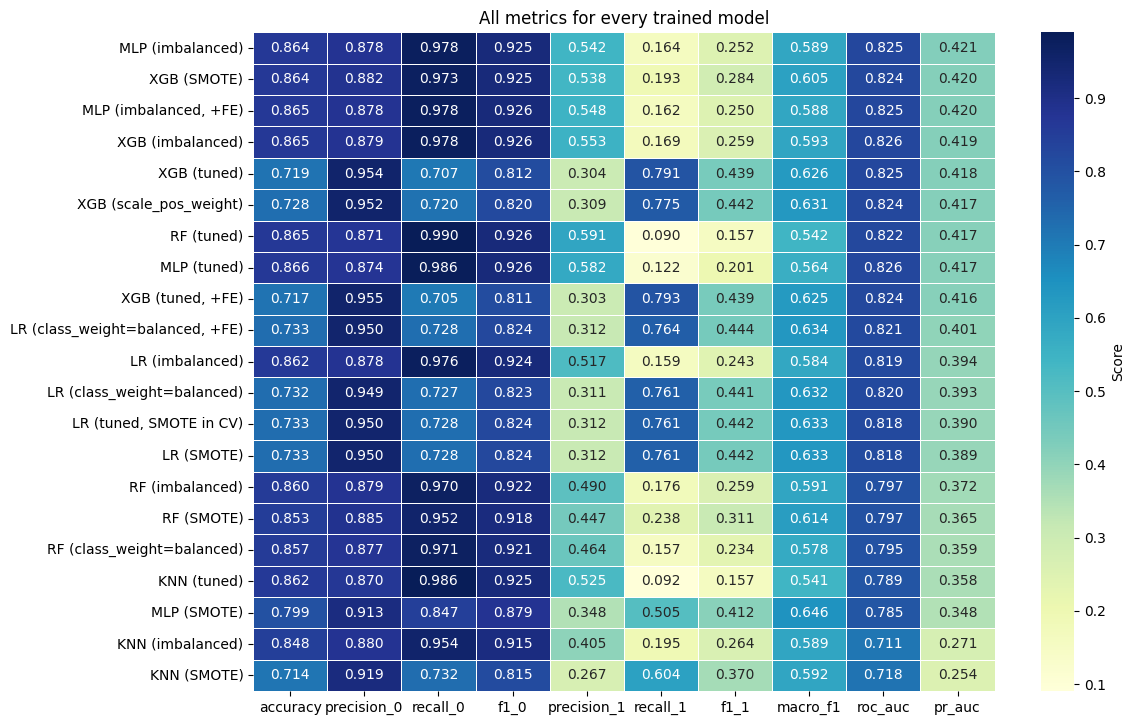


Best model per metric:
  pr_auc       -> MLP (imbalanced)                         (0.4211)
  roc_auc      -> MLP (tuned)                              (0.8257)
  macro_f1     -> MLP (SMOTE)                              (0.6457)
  recall_1     -> XGB (tuned, +FE)                         (0.7929)
  f1_1         -> LR (class_weight=balanced, +FE)          (0.4436)
  accuracy     -> MLP (tuned)                              (0.8655)


In [ ]:
# Pull every evaluated model into a clean DataFrame, sorted by PR-AUC (highest first).
summary = (
    pd.DataFrame(results).T
      .round(4)
      .sort_values('pr_auc', ascending=False)
)

# Tag each row with its model family + imbalance strategy for grouped plotting
def _family(name):
    n = name.lower()
    if n.startswith('lr'):  return 'Logistic Regression'
    if n.startswith('rf'):  return 'Random Forest'
    if n.startswith('xgb'): return 'XGBoost'
    if n.startswith('knn'): return 'KNN'
    if n.startswith('mlp'): return 'MLP'
    return 'Other'

def _strategy(name):
    n = name.lower()
    if 'tuned' in n:                            return 'tuned'
    if 'smote' in n:                            return 'SMOTE'
    if 'class_weight' in n or 'scale_pos' in n: return 'reweighted'
    if 'imbalanced' in n:                       return 'baseline'
    return 'other'

summary.insert(0, 'model',    summary.index.map(_family))
summary.insert(1, 'strategy', summary.index.map(_strategy))

# --- Clean ranked table ---
display_cols = ['model', 'strategy', 'accuracy', 'precision_1', 'recall_1',
                'f1_1', 'macro_f1', 'roc_auc', 'pr_auc']
print('All models ranked by PR-AUC:\n')
display(summary[display_cols])

# --- Plot 1: grouped bar of the three headline metrics ---
metrics_to_plot = ['pr_auc', 'roc_auc', 'macro_f1']
plot_df = summary[metrics_to_plot].copy()

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')
ax.set_title('Headline metrics across all models (sorted by PR-AUC)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.axhline(0.139, ls='--', color='grey', lw=1, label='PR-AUC chance (13.9% prevalence)')
ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: precision vs recall on the positive class ---
fig, ax = plt.subplots(figsize=(10, 7))
family_colors = {
    'Logistic Regression': 'tab:blue', 'Random Forest': 'tab:green',
    'XGBoost': 'tab:red', 'KNN': 'tab:purple', 'MLP': 'tab:orange',
}
strategy_markers = {'baseline': 'o', 'SMOTE': 's', 'reweighted': '^', 'tuned': 'D'}

for name, row in summary.iterrows():
    ax.scatter(
        row['recall_1'], row['precision_1'],
        c=family_colors.get(row['model'], 'grey'),
        marker=strategy_markers.get(row['strategy'], 'x'),
        s=140, edgecolors='black', linewidths=0.7, alpha=0.85,
    )
    ax.annotate(name, (row['recall_1'], row['precision_1']),
                xytext=(5, 4), textcoords='offset points', fontsize=8)

from matplotlib.lines import Line2D
fam_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                      markersize=10, label=k) for k,c in family_colors.items()]
strat_handles = [Line2D([0],[0], marker=m, color='w', markerfacecolor='grey',
                        markersize=10, label=k) for k,m in strategy_markers.items()]
l1 = ax.legend(handles=fam_handles,   title='Model family', loc='upper right')
ax.add_artist(l1)
ax.legend(handles=strat_handles, title='Imbalance strategy', loc='lower right')

ax.set_xlabel('Recall on Diabetes class (recall_1)')
ax.set_ylabel('Precision on Diabetes class (precision_1)')
ax.set_title('Precision vs Recall on the positive class — imbalance strategies shift the operating point')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# --- Plot 3: heatmap of all metrics ---
heat_cols = ['accuracy', 'precision_0', 'recall_0', 'f1_0',
             'precision_1', 'recall_1', 'f1_1', 'macro_f1', 'roc_auc', 'pr_auc']
plt.figure(figsize=(12, max(4, 0.35 * len(summary))))
sns.heatmap(
    summary[heat_cols], annot=True, fmt='.3f', cmap='YlGnBu',
    cbar_kws={'label': 'Score'}, linewidths=0.4,
)
plt.title('All metrics for every trained model')
plt.ylabel('')
plt.tight_layout()
plt.show()

# --- Winners by metric ---
print('\nBest model per metric:')
for m in ['pr_auc', 'roc_auc', 'macro_f1', 'recall_1', 'f1_1', 'accuracy']:
    best = summary[m].idxmax()
    print(f'  {m:12s} -> {best:40s} ({summary.loc[best, m]:.4f})')

Plotting 17 of 21 models (reweighted points hidden for clarity).


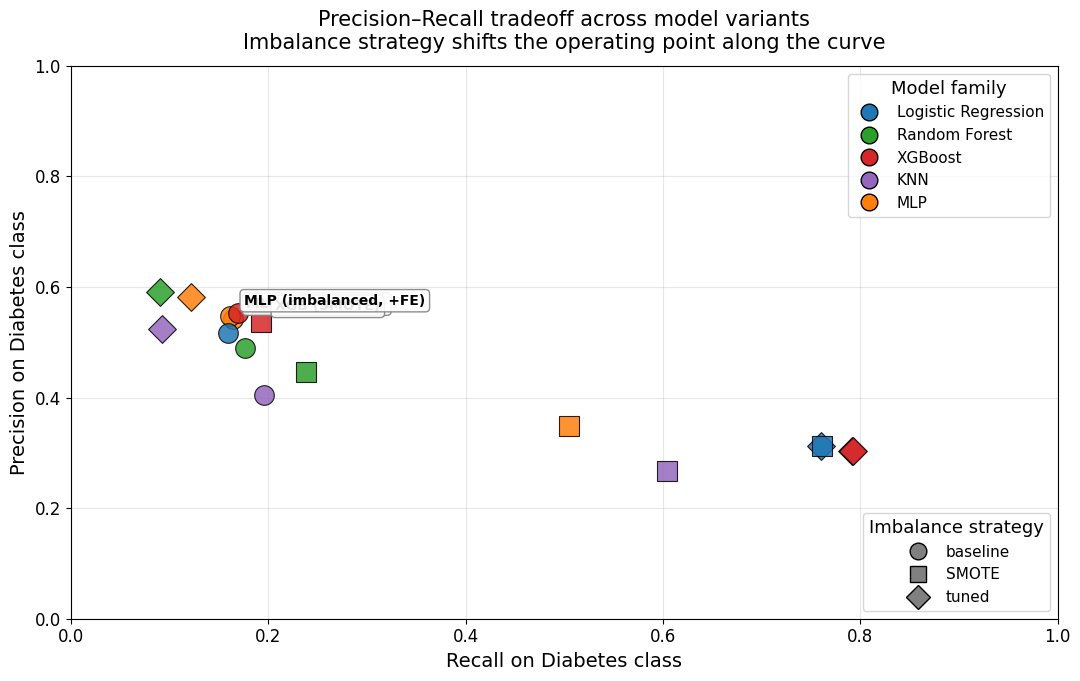

Saved: results_slide_precision_recall.png (300 DPI)


In [ ]:
from matplotlib.lines import Line2D

# Larger fonts for a slide — applied only inside this cell via rc_context
slide_rc = {
    'font.size':       13,
    'axes.titlesize':  15,
    'axes.labelsize':  14,
    'legend.fontsize': 11,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}

family_colors = {
    'Logistic Regression': 'tab:blue',
    'Random Forest':       'tab:green',
    'XGBoost':              'tab:red',
    'KNN':                  'tab:purple',
    'MLP':                  'tab:orange',
}
# 'reweighted' dropped for slide clarity
strategy_markers = {'baseline': 'o', 'SMOTE': 's', 'tuned': 'D'}

# Filter out reweighted rows for the slide figure only
slide_df = summary[summary['strategy'] != 'reweighted']
print(f'Plotting {len(slide_df)} of {len(summary)} models (reweighted points hidden for clarity).')

with plt.rc_context(slide_rc):
    fig, ax = plt.subplots(figsize=(11, 7))

    # All points — color = family, marker = imbalance strategy
    for name, row in slide_df.iterrows():
        ax.scatter(
            row['recall_1'], row['precision_1'],
            c=family_colors.get(row['model'], 'grey'),
            marker=strategy_markers.get(row['strategy'], 'x'),
            s=200, edgecolors='black', linewidths=0.8, alpha=0.85, zorder=3,
        )

    # Label only the top-3 models (from the filtered set) by PR-AUC
    for name, row in slide_df.head(3).iterrows():
        ax.annotate(
            name,
            (row['recall_1'], row['precision_1']),
            xytext=(10, 8), textcoords='offset points',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='grey', alpha=0.9),
        )

    # Two legends: family (colors) and strategy (markers)
    fam_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                          markersize=12, markeredgecolor='black', label=k)
                   for k, c in family_colors.items()]
    strat_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='grey',
                            markersize=12, markeredgecolor='black', label=k)
                     for k, m in strategy_markers.items()]

    l1 = ax.legend(handles=fam_handles, title='Model family',
                   loc='upper right', frameon=True)
    ax.add_artist(l1)
    ax.legend(handles=strat_handles, title='Imbalance strategy',
              loc='lower right', frameon=True)

    ax.set_xlabel('Recall on Diabetes class')
    ax.set_ylabel('Precision on Diabetes class')
    ax.set_title(
        'Precision\u2013Recall tradeoff across model variants\n'
        'Imbalance strategy shifts the operating point along the curve',
        pad=12,
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig('results_slide_precision_recall.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Saved: results_slide_precision_recall.png (300 DPI)')